# Problem Statement

Scaler is an online tech-versity offering intensive computer science & Data Science courses through live classes delivered by tech leaders and subject matter experts. The meticulously structured program enhances the skills of software professionals by offering a modern curriculum with exposure to the latest technologies. It is a product by InterviewBit.

You are working as a data scientist with the analytics vertical of Scaler, focused on profiling the best companies and job positions to work for from the Scaler database. You are provided with the information for a segment of learners and tasked to cluster them on the basis of their job profile, company, and other features. Ideally, these clusters should have similar characteristics.

**Data Dictionary:**

* Unnamed 0 - Index of the dataset
* Email_hash - Anonymised Personal Identifiable Information (PII)
* Company_hash - This represents an anonymized identifier for the company, which is the current employer of the learner.
* orgyear - Employment start date
* CTC - Current CTC
* Job_position - Job profile in the company
* CTC_updated_year - Year in which CTC got updated (Yearly increments, Promotions)

**Concept Used:**

* Manual Clustering
* Unsupervised Clustering - K- means, Hierarchical Clustering

# Importing all the necessary libraries

In [1]:
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Loading the dataset

In [2]:
df = pd.read_csv("scaler_clustering_kmeans.csv")
df.head()

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


In [3]:
df.shape

(205843, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205843 entries, 0 to 205842
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        205843 non-null  int64  
 1   company_hash      205799 non-null  object 
 2   email_hash        205843 non-null  object 
 3   orgyear           205757 non-null  float64
 4   ctc               205843 non-null  int64  
 5   job_position      153281 non-null  object 
 6   ctc_updated_year  205843 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 11.0+ MB


In [5]:
df.isna().sum()

Unnamed: 0              0
company_hash           44
email_hash              0
orgyear                86
ctc                     0
job_position        52562
ctc_updated_year        0
dtype: int64

In [6]:
round((df.isna().sum()/len(df)) * 100, 2)

Unnamed: 0           0.00
company_hash         0.02
email_hash           0.00
orgyear              0.04
ctc                  0.00
job_position        25.53
ctc_updated_year     0.00
dtype: float64

In [7]:
df.describe()

,Unnamed: 0,orgyear,ctc,ctc_updated_year
count,205843.000000,205757.000000,2.058430e+05,205843.000000
mean,103273.941786,2014.882750,2.271685e+06,2019.628231
std,59741.306484,63.571115,1.180091e+07,1.325104
min,0.000000,0.000000,2.000000e+00,2015.000000
25%,51518.500000,2013.000000,5.300000e+05,2019.000000
50%,103151.000000,2016.000000,9.500000e+05,2020.000000
75%,154992.500000,2018.000000,1.700000e+06,2021.000000
max,206922.000000,20165.000000,1.000150e+09,2021.000000


In [8]:
df.describe(exclude=['float64','int64'])

,company_hash,email_hash,job_position
count,205799,205843,153281
unique,37299,153443,1017
top,nvnv wgzohrnvzwj otqcxwto,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,Backend Engineer
freq,8337,10,43554


**Observations:**

* There are 205843 rows and 7 columns
* Null Values observed in 3 columns
* Backend Engineer is the most frequent Job Position in the dataset.
* Further analysis can be better performed post EDA, handling null, duplicates and outliers

# Data Preprocessing

* Data Cleaning
* Checking Duplicates and Treatment
* Checking Outliers and Treatment using Capping
* Checking Null Values and Treatment using KNN imputation for Numerical attributes
* Remove Special characters using Regex
* Feature Engineering

In [9]:
df1=df.copy()

**Regex for Cleaning Company Names**

In [10]:
import re

In [11]:
# Function to clean special characters
def clean_string(s):
    if not isinstance(s, str):
        s = str(s)
    return re.sub('[^A-Za-z0-9 ]+', '', s)

# Apply the function to the 'company_hash' column
df1['company_hash'] = df1['company_hash'].apply(clean_string)

**Check duplicates**

In [12]:
df1.duplicated().any()

False

No Duplicate rows observed overall in the dataset


**Check Duplicates based on Email_hash and remove them to ensure uniqueness of each learner's data**

In [13]:
combined_duplicates = df[df.duplicated(subset=['email_hash'], keep=False)]
print(f'Number of duplicate rows based on "email_hash": {combined_duplicates.shape[0]}')

# Display the duplicate rows
print(combined_duplicates)

Number of duplicate rows based on "email_hash": 93616
        Unnamed: 0                         company_hash  \
0                0                       atrgxnnt xzaxv   
1                1            qtrxvzwt xzegwgbb rxbxnta   
2                2                        ojzwnvwnxw vx   
4                4                           qxen sqghu   
5                5  yvuuxrj hzbvqqxta bvqptnxzs ucn rna   
...            ...                                  ...   
205827      206907                             btaxvztn   
205830      206910                       zgn vuurxwvmrt   
205831      206911             tcxct ogenfvqt vzvrjnxwo   
205837      206917                       zgn vuurxwvmrt   
205838      206918                            vuurt xzw   

                                               email_hash  orgyear      ctc  \
0       6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...   2016.0  1100000   
1       b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...   2018.0   449999   


In [14]:
df1= df1.drop_duplicates(subset=['email_hash'], keep='last')

* Removed Duplicates based on Email_hash
* Multiple individuals can be associated with the same company, so using company_hash alone may not ensure the uniqueness of learners
* Could have considered both Email and Company for duplicate. This would have ensured that we don't remove valid records where the same individual is associated with multiple companies. But with limited information currently going ahead with removing duplicates based on Email_hash to ensure uniqueness of each learner's data

**Check null values**

In [15]:
df1.isna().sum()

Unnamed: 0              0
company_hash            0
email_hash              0
orgyear                79
ctc                     0
job_position        34189
ctc_updated_year        0
dtype: int64

* job_position has high number of null values
* orgyear have got few null values
* Will treat null values upon further analysis

***Check Unique Values for Each Feature and Convert Data type if needed***


In [16]:
# Non-numeric columns
obj_cols = df1.select_dtypes(include='object').columns
obj_cols

Index(['company_hash', 'email_hash', 'job_position'], dtype='object')

In [17]:
for _ in obj_cols:
    print()
    print(f'Total Unique Values in {_} column are :- {df1[_].nunique()}')
    print(f'Value counts in {_} column are :-\n {df1[_].value_counts()}')
    print()
    print('-'*120)


Total Unique Values in company_hash column are :- 36366
Value counts in company_hash column are :-
 nvnv wgzohrnvzwj otqcxwto         5336
xzegojo                           3526
vbvkgz                            2440
wgszxkvzn                         2199
zgn vuurxwvmrt vwwghzn            2192
                                  ... 
bgovbmtt                             1
wrxd wvuxnvr otqcxwto ucn rna        1
vxs mhoxztoo ogrhnxgzo ucn rna       1
uhroho                               1
bvptbjnqxu td vbvkgz                 1
Name: company_hash, Length: 36366, dtype: int64

------------------------------------------------------------------------------------------------------------------------

Total Unique Values in email_hash column are :- 153443
Value counts in email_hash column are :-
 effdede7a2e7c2af664c8a31d9346385016128d66bbc58a44274d5d6876dfec7    1
d8e8d73114617d98f7b647d6a2943983564978c3999509d98d6d5142714c7958    1
0a2c6b808187b21a9ab6b27f2365dc315cd4f64c5c908f12e387303a340dbd

* Since company and email are hashed so not much information can be inferred. However, we can conveniently identify contribution of each element to the Feature
* Since email_hash is unique for every learner so it is correctly showing frequency as 1 for each email
* Backend Engineer is the most frequent with 33154 value counts followed by FullStack Engineer and Other

In [18]:
# Numeric columns
num_cols = df1.select_dtypes(include='number').columns
num_cols

Index(['Unnamed: 0', 'orgyear', 'ctc', 'ctc_updated_year'], dtype='object')

In [19]:
for _ in num_cols:
    print()
    print(f'Total Unique Values in {_} column are :- {df1[_].nunique()}')
    print(f'Value counts in {_} column are :-\n {df1[_].value_counts(normalize=True)}')
    print()
    print('-'*120)


Total Unique Values in Unnamed: 0 column are :- 153443
Value counts in Unnamed: 0 column are :-
 3         0.000007
150149    0.000007
150151    0.000007
150152    0.000007
150153    0.000007
            ...   
82865     0.000007
82866     0.000007
82867     0.000007
82868     0.000007
206922    0.000007
Name: Unnamed: 0, Length: 153443, dtype: float64

------------------------------------------------------------------------------------------------------------------------

Total Unique Values in orgyear column are :- 76
Value counts in orgyear column are :-
 2016.0    0.112993
2018.0    0.109661
2017.0    0.107985
2015.0    0.104249
2019.0    0.098022
            ...   
2106.0    0.000007
1973.0    0.000007
209.0     0.000007
208.0     0.000007
200.0     0.000007
Name: orgyear, Length: 76, dtype: float64

------------------------------------------------------------------------------------------------------------------------

Total Unique Values in ctc column are :- 3299
Value counts i

* Unnamed: 0 do not provide any useful information, will drop this column
* ctc_updated_year to be converted to datetime datatype for further analysis
* orgyear is the starting year of employment. We could identify many invalid entries like 200,208,2107 ..which are not valid years. This column will undergo treatment
* Maximum Learners have got CTC of 6 Lac followed by 10 Lac and 4 Lac

**Removing column 'Unnamed: 0' as it does not have any useful information**

In [20]:
df1 = df1.drop(columns=['Unnamed: 0'])

**Convert Required Columns to Datetime datatype**

In [21]:
df1['ctc_updated_year'] = pd.to_datetime(df1['ctc_updated_year'], format='%Y')
df1['ctc_updated_year'] = df1['ctc_updated_year'].dt.year

**Treatment of column 'orgyear'**

orgyear is the starting year of employment. We could identify many invalid entries like 200,208,2107 ..which are not valid years.



In [22]:
# Define the range of valid years (e.g., 1900 to 2023)
valid_years = range(1900, 2024)

# Replace invalid years with NaN
df1['orgyear'] = df1['orgyear'].apply(lambda x: x if x in valid_years else np.nan)

# Convert valid years to datetime
df1['orgyear'] = pd.to_datetime(df1['orgyear'].dropna().astype(int), format='%Y')
df1['orgyear'] = df1['orgyear'].dt.year
df1['orgyear']=df1['orgyear'].astype('Int64')

**Treatment of Null Values**

In [23]:
df1.isna().sum()

company_hash            0
email_hash              0
orgyear               186
ctc                     0
job_position        34189
ctc_updated_year        0
dtype: int64

**KNN Imputation for Numerical Column**

In [24]:
# Impute missing values in Job Position column with 'Other'
df1['job_position'].fillna('unknown', inplace=True)

# Impute missing values in numerical columns using KNN
knn_imputer = KNNImputer(n_neighbors=3)

# Select only numerical columns for KNN imputation
numerical_cols = ['orgyear']

# Fit and transform the KNN imputer on the numerical columns
df1[numerical_cols] = knn_imputer.fit_transform(df1[numerical_cols])

In [25]:
# Convert orgyear back to int
df1['orgyear'] = df1['orgyear'].astype(int)

* For job_position, filled missing values with the string 'unknown'. This ensures that the analysis considers these entries as a separate category rather than skewing the distribution of existing categories. This approach maintains the integrity of the categorical data while addressing missing values in a straightforward and non-biased manner.
* Applied KNN imputation to fill missing values in the orgyear column. This leverages the relationships between existing data points to predict the missing values.

**Feature Engineering**

Creating new feature 'YOE' Years of Experience

In [26]:
# Get the current year
current_year = datetime.now().year

# Create the YOE column by subtracting orgyear from current_year
df1['YOE'] = current_year - df1['orgyear']

df1.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,YOE
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017,700000,Backend Engineer,2019,8
7,vwwtznhqt ntwyzgrgsj,756d35a7f6bb8ffeaffc8fcca9ddbb78e7450fa0de2be0...,2019,400000,Backend Engineer,2019,6
9,xrbhd,b2dc928f4c22a9860b4a427efb8ab761e1ce0015fba1a5...,2019,360000,unknown,2019,6
13,wgszxkvzn,134cc4a76a119493d523f1855a3b7106f64287455d5cd4...,2016,440000,Data Analyst,2020,9
14,xznhxn,ebcaf397ef5084e05889a6e9a0c3f96a5c8fb0b16749ce...,2016,440000,Backend Engineer,2019,9


**Checking Outliers**

In [27]:
df2=df1.copy()

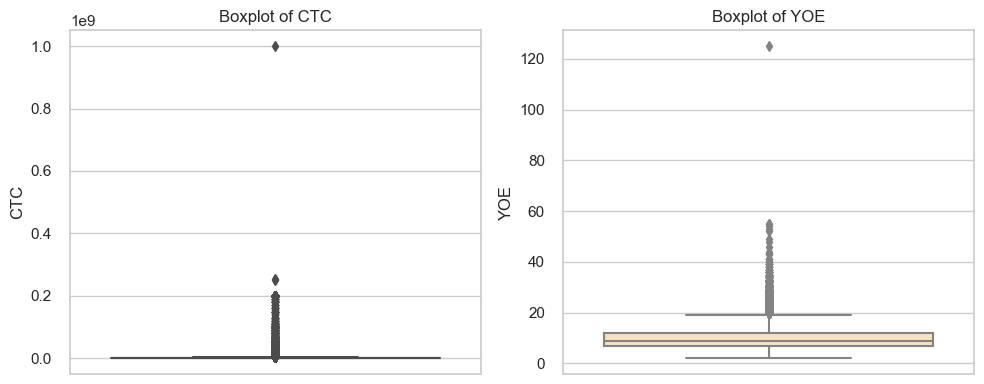

In [28]:
# Set the style of seaborn
sns.set(style='whitegrid')

# Create a figure with two subplots for CTC and YOE
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Boxplot for CTC
sns.boxplot(data=df2, y='ctc', ax=ax[0])
ax[0].set_title('Boxplot of CTC')
ax[0].set_ylabel('CTC')

# Boxplot for YOE
sns.boxplot(data=df2, y="YOE", ax=ax[1], color='moccasin')
ax[1].set_title('Boxplot of YOE')
ax[1].set_ylabel('YOE')

# Show the plots
plt.tight_layout()
plt.show()

* We can clearly observe outliers in ctc and YOE
* Outliers can significantly impact the performance and results of clustering algorithms like K-means and hierarchical clustering

**Treatment of Outliers**

Used Capping method to treat outliers. This approach reduces the impact of extreme outliers without completely removing data points.

In [29]:
# Calculate upper bound for ctc using 99th percentile
ctc_upper_bound = df2['ctc'].quantile(0.99)

# Apply clipping to ctc column
df2['ctc_capped'] = np.clip(df2['ctc'], df2['ctc'].min(), ctc_upper_bound)

In [30]:
# Calculate upper bound for YOE using 99th percentile
yoe_upper_bound = df2['YOE'].quantile(0.99)

# Apply clipping to YOE column
df2['YOE_capped'] = np.clip(df2['YOE'], df2['YOE'].min(), yoe_upper_bound)

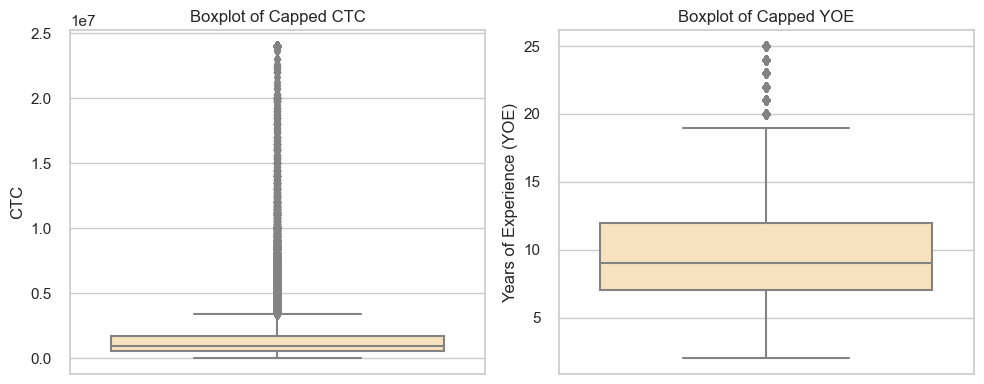

In [31]:
# Set the style of seaborn
sns.set(style="whitegrid")

# Create a figure with two subplots for CTC and YOE
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Boxplot for CTC post Capping
sns.boxplot(data=df2, y='ctc_capped', ax=ax[0],color='moccasin')
ax[0].set_title('Boxplot of Capped CTC')
ax[0].set_ylabel('CTC')

# Boxplot for YOE post Capping
sns.boxplot(data=df2, y='YOE_capped', ax=ax[1],color='moccasin')
ax[1].set_title('Boxplot of Capped YOE')
ax[1].set_ylabel('Years of Experience (YOE)')

# Show the plots
plt.tight_layout()
plt.show()

* We can observe that extreme outliers have been treated with capping method.
* Setting the upper percentile to 99% is a way to include most of the data points while excluding the extreme 1% of outliers that are far from the rest of the data.
* This approach ensured that the majority of data remains intact, while the extreme values that could significantly impact the clustering results are capped.
* Created two new capped columns while keeping the original columns if needed to refer further

In [32]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 153443 entries, 3 to 205842
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   company_hash      153443 non-null  object
 1   email_hash        153443 non-null  object
 2   orgyear           153443 non-null  int32 
 3   ctc               153443 non-null  int64 
 4   job_position      153443 non-null  object
 5   ctc_updated_year  153443 non-null  int64 
 6   YOE               153443 non-null  int32 
 7   ctc_capped        153443 non-null  int64 
 8   YOE_capped        153443 non-null  int32 
dtypes: int32(3), int64(3), object(3)
memory usage: 10.0+ MB


# Manual Clustering

* Creating Designation Flag & Insights
* Creating Class Flag & Insights
* Creating Tier Flag & Insights

In [33]:
df3 = df2.copy()

Dropping original columns ctc and YOE for capped_ctc and capped_YOE

* Analysis will be more consistent and robust when performed on a dataset where extreme values have been controlled or standardized through capping.
* Capped Feature preserves the integrity of the dataset by retaining most data points while adjusting extreme values. This ensures that the analysis reflects the general trends and patterns in the data without being overly influenced by outliers.

In [34]:
# Drop original ctc and YOE columns
df3.drop(['ctc', 'YOE'], axis=1, inplace=True)

In [35]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 153443 entries, 3 to 205842
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   company_hash      153443 non-null  object
 1   email_hash        153443 non-null  object
 2   orgyear           153443 non-null  int32 
 3   job_position      153443 non-null  object
 4   ctc_updated_year  153443 non-null  int64 
 5   ctc_capped        153443 non-null  int64 
 6   YOE_capped        153443 non-null  int32 
dtypes: int32(2), int64(2), object(3)
memory usage: 8.2+ MB


Creating Flags:

* Designation Flag: CTC on the basis of Company, Job Position and Years of Experience
* Class Flag: CTC On the basis of Company and Job Position
* Tier Flag: CTC On the basis of Company

In [36]:
# Step 1: Group by company, job position, and years of experience (Designation)
grouped_summary_designation = df3.groupby(['company_hash',  'job_position', 'YOE_capped'])['ctc_capped'].agg(['mean', 'median', 'max', 'min', 'count']).reset_index()
grouped_summary_designation.rename(columns={'mean': 'mean_designation'}, inplace=True)

# Group by company and years of experience (Class)
grouped_summary_class = df3.groupby(['company_hash',  'job_position'])['ctc_capped'].agg(['mean', 'median', 'max', 'min', 'count']).reset_index()
grouped_summary_class.rename(columns={'mean': 'mean_class'}, inplace=True)

# Group by company level only (Tier)
grouped_summary_tier = df3.groupby(['company_hash'])['ctc_capped'].agg(['mean', 'median', 'max', 'min', 'count']).reset_index()
grouped_summary_tier.rename(columns={'mean': 'mean_tier'}, inplace=True)

# Step 2: Merge only the mean values with the original dataset
df3 = df3.merge(grouped_summary_designation[['company_hash',  'job_position', 'YOE_capped', 'mean_designation']], on=['company_hash', 'job_position', 'YOE_capped'])
df3 = df3.merge(grouped_summary_class[['company_hash',  'job_position', 'mean_class']], on=['company_hash', 'job_position'])
df3 = df3.merge(grouped_summary_tier[['company_hash', 'mean_tier']], on=['company_hash'])

# Step 3: Create flags for Designation, Class, and Tier based on mean values
def designation_flag(row):
    if row['ctc_capped'] > row['mean_designation']:
        return 3
    elif row['ctc_capped'] == row['mean_designation']:
        return 2
    else:
        return 1
    
def class_flag(row):
    if row['ctc_capped'] > row['mean_class']:
        return 3
    elif row['ctc_capped'] == row['mean_class']:
        return 2
    else:
        return 1

def tier_flag(row):
    if row['ctc_capped'] > row['mean_tier']:
        return 3
    elif row['ctc_capped'] == row['mean_tier']:
        return 2
    else:
        return 1  

df3['Designation_Flag'] = df3.apply(designation_flag, axis=1)
df3['Class_Flag'] = df3.apply(class_flag, axis=1)
df3['Tier_Flag'] = df3.apply(tier_flag, axis=1)

# Step 4: Check if columns exist before attempting to drop them
columns_to_drop = ['mean_class', 'mean_designation', 'mean_tier']
df3.drop(columns=[col for col in columns_to_drop if col in df3.columns], inplace=True)

In [37]:
grouped_summary_designation.head()

,company_hash,job_position,YOE_capped,mean_designation,median,max,min,count
0,0,Other,5,100000.0,100000.0,100000,100000,1
1,0000,Other,8,300000.0,300000.0,300000,300000,1
2,01 ojztqsj,Android Engineer,9,270000.0,270000.0,270000,270000,1
3,01 ojztqsj,Frontend Engineer,14,830000.0,830000.0,830000,830000,1
4,05mz exzytvrny uqxcvnt rxbxnta,Backend Engineer,6,1100000.0,1100000.0,1100000,1100000,1


In [38]:
grouped_summary_class.head()

,company_hash,job_position,mean_class,median,max,min,count
0,0,Other,100000.0,100000.0,100000,100000,1
1,0000,Other,300000.0,300000.0,300000,300000,1
2,01 ojztqsj,Android Engineer,270000.0,270000.0,270000,270000,1
3,01 ojztqsj,Frontend Engineer,830000.0,830000.0,830000,830000,1
4,05mz exzytvrny uqxcvnt rxbxnta,Backend Engineer,1100000.0,1100000.0,1100000,1100000,1


In [39]:
grouped_summary_tier.head()

,company_hash,mean_tier,median,max,min,count
0,0,100000.0,100000.0,100000,100000,1
1,0000,300000.0,300000.0,300000,300000,1
2,01 ojztqsj,550000.0,550000.0,830000,270000,2
3,05mz exzytvrny uqxcvnt rxbxnta,1100000.0,1100000.0,1100000,1100000,1
4,1,175000.0,175000.0,250000,100000,2


In [40]:
df3.head()

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,ctc_capped,YOE_capped,Designation_Flag,Class_Flag,Tier_Flag
0,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017,Backend Engineer,2019,700000,8,1,1,1
1,ngpgutaxv,30a88256b5586ba59b25e6fe78fada76950fd65ca9f250...,2017,Backend Engineer,2021,1200000,8,3,1,1
2,ngpgutaxv,803bccee8b046cc228a77cc32e5f22704dab529b336ff7...,2017,Backend Engineer,2016,800000,8,1,1,1
3,ngpgutaxv,c9e14b4d46b1a76974a2e06bc546886cff85bd441f21b8...,2017,Backend Engineer,2019,1600000,8,3,3,1
4,ngpgutaxv,400aea75dc1316022b8c4436c60a0646fbea2962e26a5a...,2017,Backend Engineer,2019,1210000,8,3,1,1


Three new Features / Flags have been created

We can derive many insights from each of these flags, following are few explorations

**Designation Flag- Exploration**

Top 10 Employees with Designation Flag 1 (Earning More Than Most of Their Peers with Same Job Position and Experience)

In [41]:
top_10_designation1 = df3[df3['Designation_Flag'] == 1].nlargest(10, 'ctc_capped')
top_10_designation1

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,ctc_capped,YOE_capped,Designation_Flag,Class_Flag,Tier_Flag
53606,ofxssj,e6b830e44ae282c86a370685a6e3bb3aa82ec995eec5db...,2014,Other,2020,11200000,11,1,3,3
81018,vbvkgz ftm otqcxwto,0932dc8d855953b2ac63c8046c9fb33f7f554174b6c2fe...,2013,Backend Engineer,2019,11200000,12,1,3,3
78592,sqvm,ed3b3231ac4758173e68bcde8eac3842497e153d9d1832...,2015,Engineering Leadership,2019,9200000,10,1,3,3
58406,hmtq,9885423385b89dd905f1df74a1d6e71906ccccd915c7e4...,2013,Engineering Leadership,2020,8500000,12,1,3,3
5251,xzntr wgqugqvnxgz,9aa54ea5c7e0b2567cc43718bd6516f3cfefb5622b6e2b...,2015,Other,2021,8400000,10,1,3,3
65124,fvrbvqn rvmo,9adf861294aa69336409395a5474ce6f9ffbfd38594ed4...,2010,Backend Architect,2019,8100000,15,1,3,3
120274,vba,f9530fc2d3629fc9a04c7e4e2ea6b8ddbe03eb3a97caff...,2003,Engineering Leadership,2020,8100000,22,1,1,3
16855,gnytq,4f4f4bac863dc79205345fd614a4e4cd4c99718533c60d...,2017,Data Analyst,2019,7300000,8,1,3,3
62217,eqttwyvqst,28dc7d414a336ebfecf691f1db3b9cdc95b58ffede1107...,2005,Engineering Leadership,2020,7300000,20,1,3,3
70911,sggsrt,97f2289a59953b4e94f8d2436f6edf621b9a359d919bbc...,2019,FullStack Engineer,2020,7300000,6,1,3,3


Bottom 10 Employees with Designation Flag 3 (Earning Less Than Most of Their Peers with Same Job Position and Experience)

In [42]:
bottom_10_designation3  = df3[df3['Designation_Flag'] == 3].nsmallest(10, 'ctc_capped')
bottom_10_designation3 

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,ctc_capped,YOE_capped,Designation_Flag,Class_Flag,Tier_Flag
70687,xzntqcxtfmxn,23ad96d6b6f1ecf554a52f6e9b61677c7d73d8a409a143...,2013,unknown,2018,14,12,3,1,1
125629,xz rgwg,66573ebeb4fcfc496d2af1548a18a62ec3a48dae59d1cc...,2016,Backend Engineer,2016,16000,9,3,3,3
132092,xmtd,792ac1d3daa5bc5fef39e3d61e0722cce004a0b81966b1...,2016,FullStack Engineer,2021,27000,9,3,3,3
99024,wgbgag,87f95061ed13da965818fded3d19249bc6d88de3b73ff2...,2014,Backend Engineer,2017,36000,11,3,3,1
141964,kvrgqv sqghu,0b1eeb6d24629a06d29fcd410c02d0f1f2577a0a050c54...,2017,Backend Engineer,2020,40000,8,3,3,3
7830,ogwxn szqvrt,38e8416bc59782b9fb60b144657130662ec8dab8094a41...,2018,Data Scientist,2021,55000,7,3,1,1
117286,cxkqn,718ad268d9c671de079ff1c55f93e91a2d06928243ad29...,2011,Backend Engineer,2020,55000,14,3,3,3
143761,zvnxgzvr wgrrtst ge xqtrvza,fb10b6e7b4fcc82e96f5a591146046c0988c23cccb8269...,2019,Other,2019,60000,6,3,3,3
111586,wtqz,217504679c19c4738eb44eacb651c80432d3a3801f62a5...,2014,FullStack Engineer,2019,65000,11,3,3,1
76857,jvzatd,2f31b0f7d87048f22a9a6eb33526325d0b3f470185652b...,2019,Backend Engineer,2020,70000,6,3,1,1


Top 10 Employees in Each Company with Designation Flag 1

In [43]:
top_10_each_company_designation1 = df3[df3['Designation_Flag'] == 1].groupby('company_hash').apply(lambda x: x.nlargest(10, 'ctc_capped')).reset_index(drop=True)
top_10_each_company_designation1 

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,ctc_capped,YOE_capped,Designation_Flag,Class_Flag,Tier_Flag
0,1bs,9c02076a74a2b8a64a6e003fa0a2e4115fc717dacb3585...,2016,Backend Engineer,2020,2320000,9,1,3,3
1,1bs,38dfe791fc911da418b67aa989a6aa7f00b8c680c6d4e1...,2015,Backend Engineer,2019,2000000,10,1,3,3
2,1bs,c97fd1612080086b898e440529c86325ae8ddf2e9a0b60...,2015,Backend Engineer,2019,1800000,10,1,3,3
3,1bs,7c6f711001cae257c36a621abb0b6ffa249b3d92240ee4...,2014,unknown,2017,1500000,11,1,1,1
4,1bs,bde68bd40e5bf94d4af39e89c6fe8af4b0926e4286de55...,2017,unknown,2021,1300000,8,1,1,1
...,...,...,...,...,...,...,...,...,...,...
8457,zxztrtvuo,b5628c03989a151f60c89e726351817c3a62078e7c70de...,2016,FullStack Engineer,2019,575000,9,1,1,1
8458,zxztrtvuo,41367fd92cd85ecfa2e2ce76f4ff94cde287b95df93871...,2018,Frontend Engineer,2019,570000,7,1,1,1
8459,zxztrtvuo,f09524b67053af24c9e446c0dd4d861cf053470ceaf0c9...,2020,unknown,2020,550000,5,1,1,1
8460,zxztrtvuo,73ed57fdb578ccb723d176b1624bb29b0e840e89ab4230...,2019,Backend Engineer,2021,520000,6,1,1,1


**Class Flag- Exploration**

Top 10 employees of FullStack Engineer in each company earning more than their peers - Class 1

In [44]:
top_10_class1_fs = df3[(df3['job_position'] == 'FullStack Engineer') & (df3['Class_Flag'] == 1)]
top_10_class1_fs = top_10_class1_fs.groupby('company_hash').apply(lambda x: x.nlargest(10, 'ctc_capped')).reset_index(drop=True)
top_10_class1_fs

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,ctc_capped,YOE_capped,Designation_Flag,Class_Flag,Tier_Flag
0,1bs,4ccdf10738e25d4f5ac6b85572ca7454453e17c5b1091b...,2019,FullStack Engineer,2021,1350000,6,2,1,1
1,1bs,55824c4e7df3af153fdfe867c15a599a6e86432c33f7c6...,2018,FullStack Engineer,2019,1300000,7,2,1,1
2,1bs ntwyzgrgsxto ucn rna,4c1e4fa4b2a7ef873e1f2b7104790a2b85aa51cae54585...,2016,FullStack Engineer,2019,900000,9,2,1,1
3,1bs ntwyzgrgsxto ucn rna,31d074dc51e6fabd2a235c23a3d9ae0e3702cf78f270e9...,2018,FullStack Engineer,2020,800000,7,2,1,1
4,2017,03b2ac96f3c199bcf9a5b4176d63750cd522cc315537a2...,2015,FullStack Engineer,2019,380000,10,2,1,1
...,...,...,...,...,...,...,...,...,...,...
4004,zxzlvwvqn,e2377e7ee0d53d2e3a45b9687fdc9c08b136b1dc470806...,2017,FullStack Engineer,2020,2300000,8,3,1,3
4005,zxzlvwvqn,e38914706e3522ee5773627abe091edd8c6596b8519a80...,2017,FullStack Engineer,2019,900000,8,1,1,1
4006,zxztrtvuo,af742fa47c46fa167ddfaf9c22a12a31cff23717582daa...,2018,FullStack Engineer,2020,710000,7,2,1,1
4007,zxztrtvuo,b5628c03989a151f60c89e726351817c3a62078e7c70de...,2016,FullStack Engineer,2019,575000,9,1,1,1


Bottom 10 Employees of FullStack Engineer in Each Company Earning Less Than Their Peers - Class 3

In [45]:
bottom_10_class3_fs = df3[(df3['job_position'] == 'FullStack Engineer') & (df3['Class_Flag'] == 3)]
bottom_10_class3_fs = bottom_10_class3_fs.groupby('company_hash').apply(lambda x: x.nsmallest(10, 'ctc_capped')).reset_index(drop=True)
bottom_10_class3_fs

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,ctc_capped,YOE_capped,Designation_Flag,Class_Flag,Tier_Flag
0,1bs,a58fadbfbc00c007dfe6e5d5891f2dda013eb5cc66552a...,2014,FullStack Engineer,2019,1600000,11,2,3,3
1,1bs ntwyzgrgsxto ucn rna,70ba4ee689ae53a942d5a9dffe2ceae1d776ca5736e69e...,2015,FullStack Engineer,2020,2800000,10,2,3,3
2,2017,59e55425c5c878bc984e046f7664ca70e4d0df93bb21f0...,2016,FullStack Engineer,2018,500000,9,2,3,3
3,247 xrvm,e959c3dae7a03c57d6bf03d299e623be9f7e736184788b...,2008,FullStack Engineer,2018,2500000,17,2,3,1
4,247vx,f8b27f9ca749c05db8ed076d13534413b63f2a2185234d...,2014,FullStack Engineer,2020,1500000,11,1,3,1
...,...,...,...,...,...,...,...,...,...,...
3226,zxxn ntwyzgrgsxto rxbxnta,58e652d3e06d4228be0a8ac9ef8228928628299d93795f...,2014,FullStack Engineer,2020,24000000,11,3,3,3
3227,zxzlvwvqn,9002b19d0e582e7a807b96851505b9937bf8b696eaaa50...,2016,FullStack Engineer,2021,4650000,9,2,3,3
3228,zxztrtvuo,650fd4e2b40bbc033df1c93c07f9b778ce8aa5d98e8292...,2016,FullStack Engineer,2019,923000,9,3,3,1
3229,zxztrtvuo,077a6b1aa5195410e497d0fb91fe2627db85d9b9879ec7...,2016,FullStack Engineer,2020,1200000,9,3,3,1


**Tier Flag- Exploration**

Top 10 Employees Earning More Than Most of the Employees in the Company - Tier 1

In [46]:
top_10_tier1 = df3[df3['Tier_Flag'] == 1].nlargest(10, 'ctc_capped')
top_10_tier1

,company_hash,email_hash,orgyear,job_position,ctc_updated_year,ctc_capped,YOE_capped,Designation_Flag,Class_Flag,Tier_Flag
90624,mvmjrgz ytvrny,c5e7360dd9c5dd31b9b4927ccccc2f3be8f6f6a5a84963...,2015,Backend Engineer,2020,17000000,10,2,1,1
135542,aggqavoy,68f1fea4dbfb7ae2209664b93d5f57fb86912dbe516b37...,2018,Backend Engineer,2020,13500000,7,2,2,1
81001,ho mvzp,7ffb1e475e90f5bcb65de6664f24820a0049992f50cddd...,2017,Engineering Leadership,2020,12000000,8,2,2,1
91869,fvqsvbxzs,299864b7e8f632bfd7079ac1f97a18371f413dfb06a2dd...,2006,Devops Engineer,2020,10000000,19,2,2,1
101863,bvqptnxzs,a53d6b54b56d30daedbfaf860cbdbbb6cc376c60832c57...,2020,Product Designer,2021,10000000,5,2,2,1
118230,wvqttb,01a83f323a2e7dfe7561157dce0b3dd718d68511127512...,2012,Backend Engineer,2019,7200000,13,3,3,1
111306,zxbmrt ongqvst,b6c269b356f1f7fd8d0aa23957f42d832a1de3d6c58ed3...,2006,Engineering Leadership,2021,7100000,19,2,2,1
90098,zvnxgzvr vhonqvrxv mvzp,2ddbc233754a1bf09fa7e92d61a5fb8fd46f3fe7908318...,2000,Engineering Leadership,2020,7000000,25,2,2,1
98439,uqgbgrnv,093c50b3213091309f0f6dbde5254c7c8a3af80f82fc7e...,2014,FullStack Engineer,2019,7000000,11,2,2,1
118223,wvqttb,0485990d28fdbb10e494793b31dd97f94c326a93c07a2d...,2014,Data Scientist,2020,7000000,11,2,1,1


Above List shows Top 10 employees details earning more than most of the employees of the company

Top 10 Companies Based on Their CTC

In [47]:
top_10_companies = df3.groupby('company_hash')['ctc_capped'].mean().nlargest(10).reset_index()
top_10_companies

,company_hash,ctc_capped
0,2jghqaggq mrxav1 hzxctqoxnj,24000000.0
1,32255407428,24000000.0
2,3ow ogrhnxgz,24000000.0
3,99 mvkvq,24000000.0
4,agbtonxiht,24000000.0
5,aggovz mgmwvn xzaxv uqxcvnt rxbxnta,24000000.0
6,agyv tdnqvwg,24000000.0
7,ajzvbxnt vootno bvzvstbtzn,24000000.0
8,ajzvbxw oxszvr,24000000.0
9,al,24000000.0


Above is the list of Top 10 Companies with highest CTC

Top 2 Positions in Every Company Based on Their CTC

In [48]:
# top_2_positions_per_company = df3.groupby(['company_hash', 'job_position'])['ctc_capped'].mean().reset_index()
# top_2_positions_per_company = top_2_positions_per_company.groupby('company_hash').apply(lambda x: x.nlargest(2, 'ctc_capped')).reset_index(drop=True)
# top_2_positions_per_company

**INSIGHTS**

**Distribution Analysis**

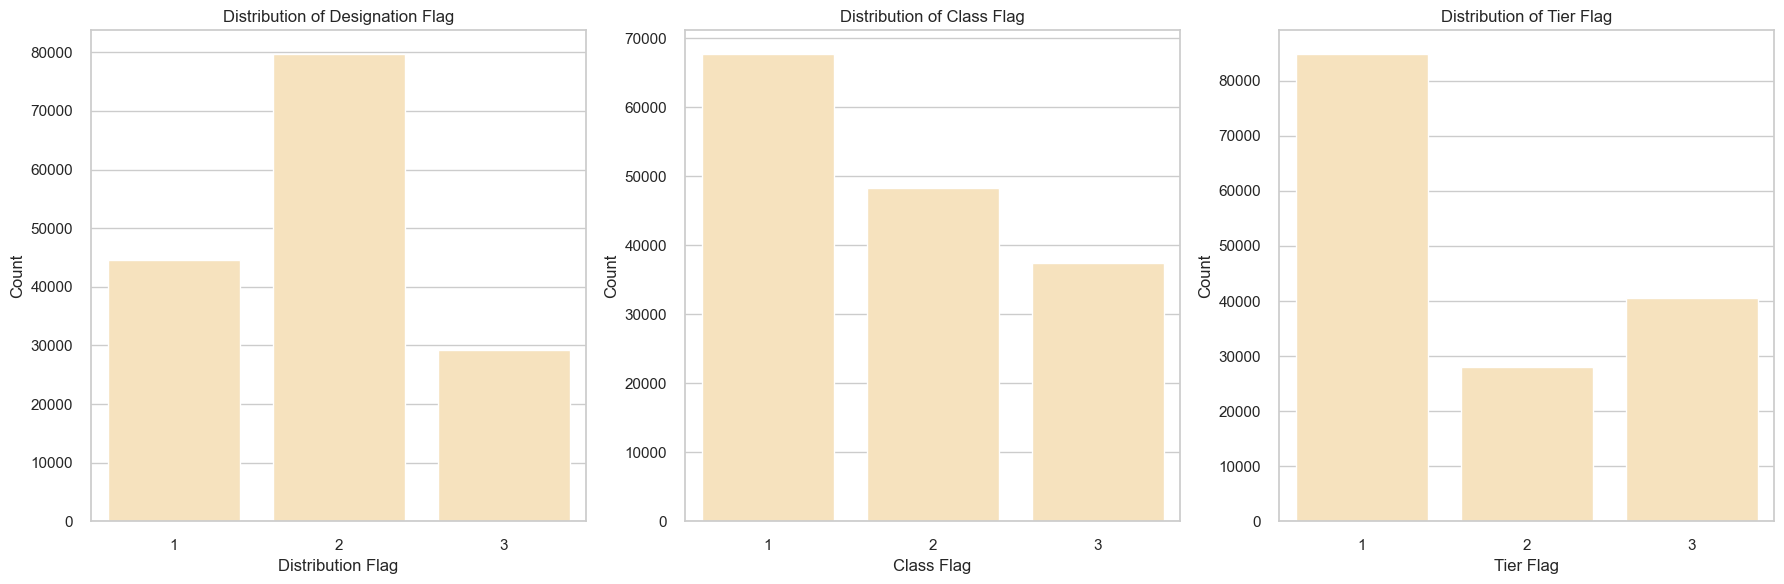

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# Plot the distribution of Designation_Flag
sns.countplot(x='Designation_Flag', data=df3, ax=axes[0], color="Moccasin")
axes[0].set_title('Distribution of Designation Flag')
axes[0].set_xlabel('Distribution Flag')
axes[0].set_ylabel('Count')

# Plot the distribution of Class_Flag
sns.countplot(x='Class_Flag', data=df3, ax=axes[1], color='moccasin')
axes[1].set_title('Distribution of Class Flag')
axes[1].set_xlabel('Class Flag')
axes[1].set_ylabel('Count')

# Plot the distribution of Class_Flag
sns.countplot(x='Tier_Flag', data=df3, ax=axes[2], color='moccasin')
axes[2].set_title('Distribution of Tier Flag')
axes[2].set_xlabel('Tier Flag')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


* Class Flag distribution looks more balanced as compared to Designation and Tier Flag

Q. Discuss the distribution of learners based on the Tier flag:

1. Which companies dominate in Tier 1 and why might this be the case?
2. Are there any notable patterns or insights when comparing learners from Tier 3 across different companies?

In [50]:
# Filter for Tier 1 learners
tier_1_learners = df3[df3['Tier_Flag'] == 1]

# Count learners in Tier 1 for each company
tier_1_company_counts = tier_1_learners['company_hash'].value_counts().reset_index()
tier_1_company_counts.columns = ['company_hash', 'count']

# Top companies in Tier 1
top_tier_1_companies = tier_1_company_counts.head(10)
print(top_tier_1_companies)


                company_hash  count
0  nvnv wgzohrnvzwj otqcxwto   4642
1                    xzegojo   2947
2     zgn vuurxwvmrt vwwghzn   1804
3                  wgszxkvzn   1783
4                  vwwtznhqt   1660
5                     vbvkgz   1564
6              fxuqg rxbxnta   1513
7                     gqvwrt   1136
8                  wvustbxzx   1039
9                        zvz    983


In [51]:
# Filter for Tier 3 learners
tier_3_learners = df3[df3['Tier_Flag'] == 3]

# Count learners in Tier 1 for each company
tier_3_company_counts = tier_3_learners['company_hash'].value_counts().reset_index()
tier_3_company_counts.columns = ['company_hash', 'count']

# Top companies in Tier 1
top_tier_3_companies = tier_3_company_counts.head(10)
print(top_tier_3_companies)

                company_hash  count
0                     vbvkgz    876
1  nvnv wgzohrnvzwj otqcxwto    694
2                     gqvwrt    611
3                  bxwqgogen    592
4                    xzegojo    579
5                  wgszxkvzn    416
6                        zvz    416
7     zgn vuurxwvmrt vwwghzn    388
8                      vagmt    366
9                  wvustbxzx    336


1. Companies Dominating in Tier 1

Common Factors: Companies dominating Tier 1 might have a large number of entry-level positions or companies that offer lower-than-average compensation.

Possible Reasons: Large enterprises with many junior or mid-level positions. Companies in traditional industries or smaller firms with limited budgets. 

2. Patterns in Tier 3 Across Different Companies

High CTC Companies: Companies with a high number of Tier 3 learners might be in tech, finance, or other high-paying sectors.

Career Progression: These companies might offer better career progression and compensation growth.

Retention Strategy: Higher compensation could be a strategy to retain top talent.

**Summary Statistics**

In [52]:
designation_summary = df3.groupby('Designation_Flag')['ctc_capped'].describe()
class_summary = df3.groupby('Class_Flag')['ctc_capped'].describe()
tier_summary = df3.groupby('Tier_Flag')['ctc_capped'].describe()

In [53]:
designation_summary

,count,mean,std,min,25%,50%,75%,max
Designation_Flag,,,,,,,,
1,44534.0,8.965103e+05,7.123804e+05,2.0,400000.0,698000.0,1200000.0,11200000.0
2,79745.0,1.606712e+06,2.846578e+06,15.0,550000.0,950000.0,1700000.0,24000000.0
3,29164.0,2.508838e+06,3.605452e+06,14.0,1000000.0,1600000.0,2650000.0,24000000.0


In [54]:
class_summary

,count,mean,std,min,25%,50%,75%,max
Class_Flag,,,,,,,,
1,67732.0,9.048633e+05,6.766390e+05,2.0,450000.0,710000.0,1200000.0,20000000.0
2,48358.0,1.520279e+06,3.011210e+06,24.0,490000.0,810000.0,1500000.0,24000000.0
3,37353.0,2.848884e+06,3.778293e+06,16.0,1200000.0,1900000.0,3000000.0,24000000.0


In [55]:
tier_summary

,count,mean,std,min,25%,50%,75%,max
Tier_Flag,,,,,,,,
1,84894.0,8.710126e+05,5.787411e+05,2.0,450000.0,730000.0,1150000.0,17000000.0
2,28069.0,1.491308e+06,3.280566e+06,24.0,400000.0,730000.0,1310000.0,24000000.0
3,40480.0,3.098245e+06,3.936230e+06,16.0,1400000.0,2100000.0,3200000.0,24000000.0


* Mean CTC in all the categories and under each flag is similar
* Maximum CTC in flags 2 and 3 of all the categories is same

**Visualizing Mean Compensation**

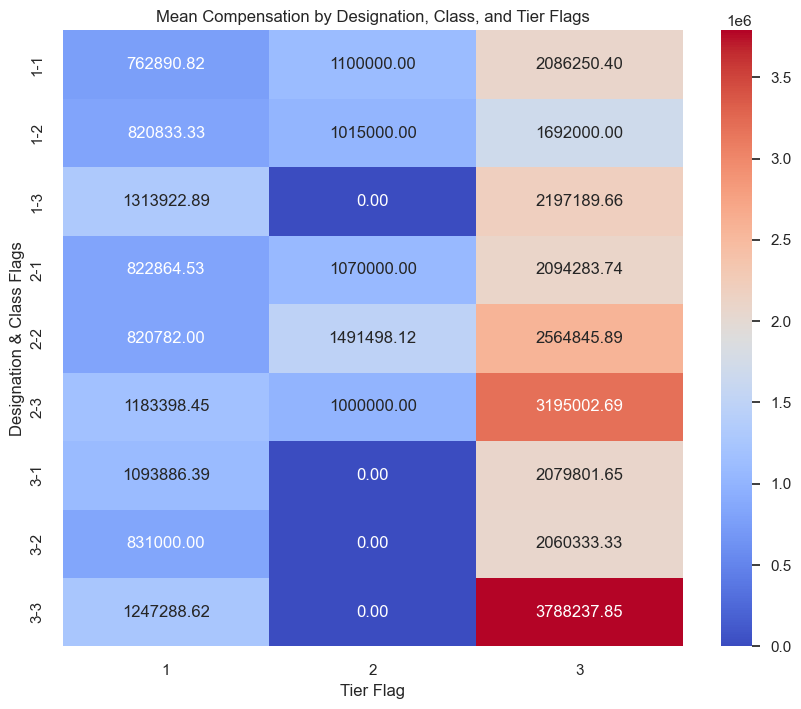

In [56]:
# Mean compensation by flags
mean_compensation_flags = df3.groupby(['Designation_Flag', 'Class_Flag', 'Tier_Flag'])['ctc_capped'].mean().unstack().fillna(0)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(mean_compensation_flags, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Mean Compensation by Designation, Class, and Tier Flags')
plt.xlabel("Tier Flag")
plt.ylabel('Designation & Class Flags')
plt.show()

* Mean CTC in Designation Flag 3 , Class Flag 3 and Tier Flag 3 are highly correlated
* Followed by mean CTC of D2, C3 and T3
* Tier 2 ctc is not correlated to D3 and any of the flag of Class

# Exploratory Data Analysis

* UniVariate Analysis
* BiVariate Analysis
* Statistical Summary

**Categorical Feature Distribution**


In [57]:
obj_cols = ['company_hash', 'job_position', 'orgyear']
num_cols= ['ctc_capped','YOE_capped']

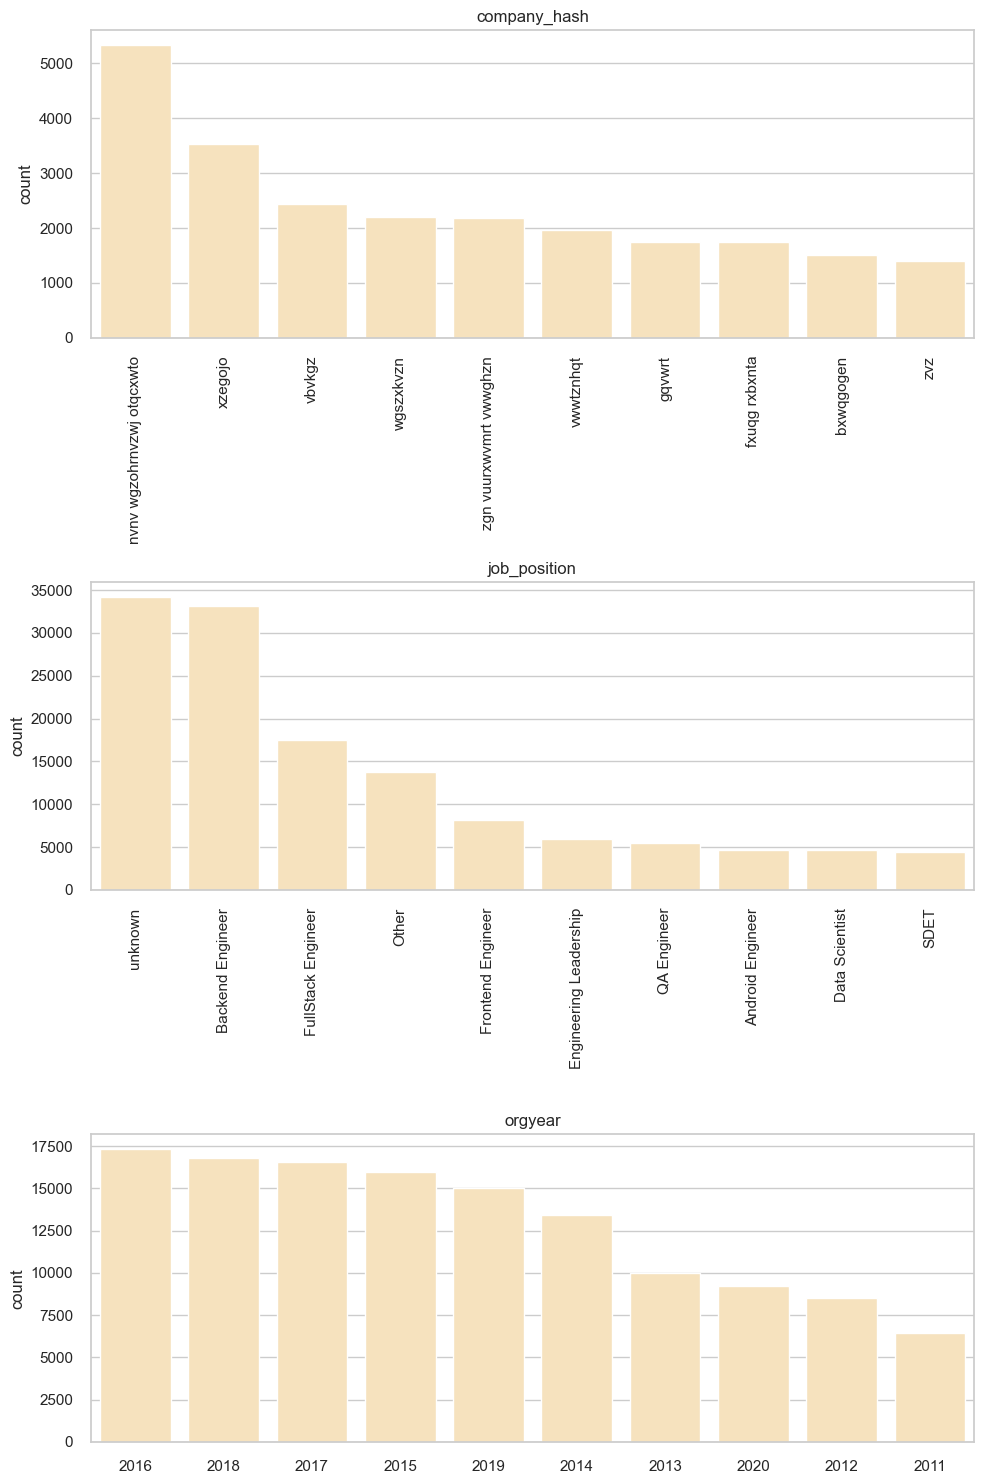

In [58]:
plt.figure(figsize=(10, 15))
i = 1

for col in obj_cols:
    top_10 = df3[col].value_counts().nlargest(10)
    top_10_index = top_10.index
    
    ax = plt.subplot(3, 1, i)
    sns.countplot(x=df3[col], order=top_10_index, color="moccasin")
    plt.title(f'{col}')
    if i <= 2:
        plt.xticks(rotation=90)
        
    ax.set_xlabel('')
    i += 1

plt.tight_layout()
plt.show()

Highlights:

* We can easily find top 10 companies in terms of count in the dataset
* Top job position is 'unknown' followed by 'Backend Engineer' and 'FullStack Engineer'
* Most of the employees started working in the year 2016 followed by 2018 and 2017

**Numerical Feature Distribution**

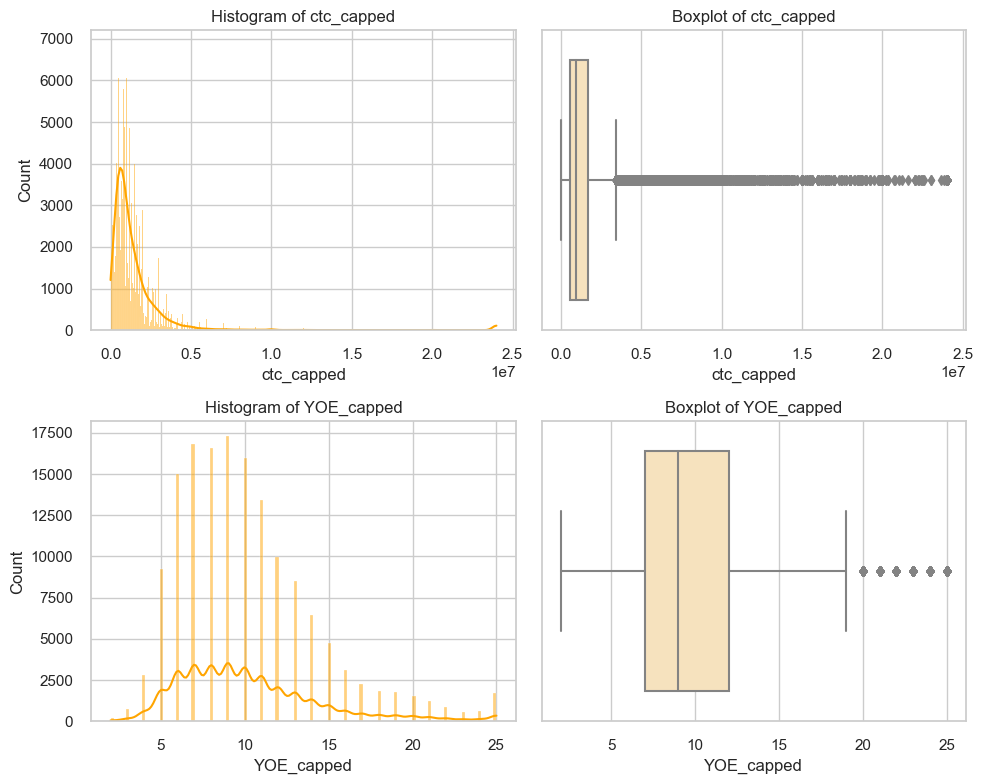

In [59]:
plt.figure(figsize=(10, 8))

# Loop through each numerical column and plot histogram and boxplot
for i, col in enumerate(num_cols):
    # Histogram
    ax1 = plt.subplot(2, 2, 2*i + 1)
    sns.histplot(df3[col], kde=True, color='orange')
    plt.title(f'Histogram of {col}')

    # Boxplot
    ax2 = plt.subplot(2, 2, 2*i + 2)
    sns.boxplot(x=df3[col], color='moccasin')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

**CTC vs Years of Experience**



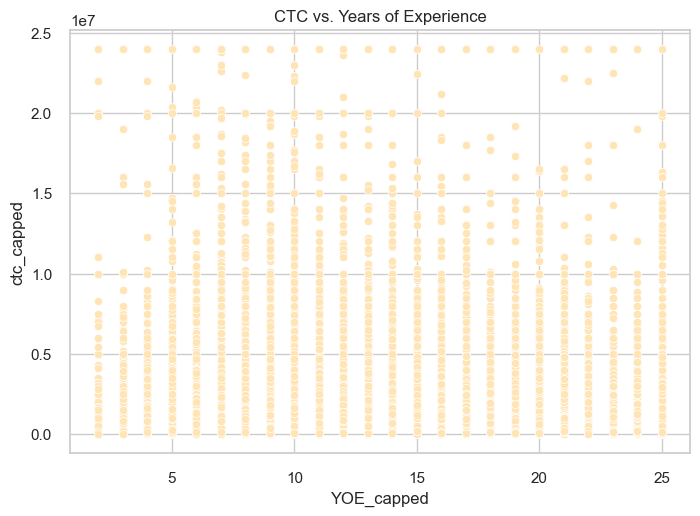

In [60]:
sns.scatterplot(x='YOE_capped', y='ctc_capped', data=df3, color='moccasin')
plt.title('CTC vs. Years of Experience')
plt.show()

There is no linear relationship or any specific pattern between Years of Experience and CTC

**Years of Experience vs Avg. CTC**

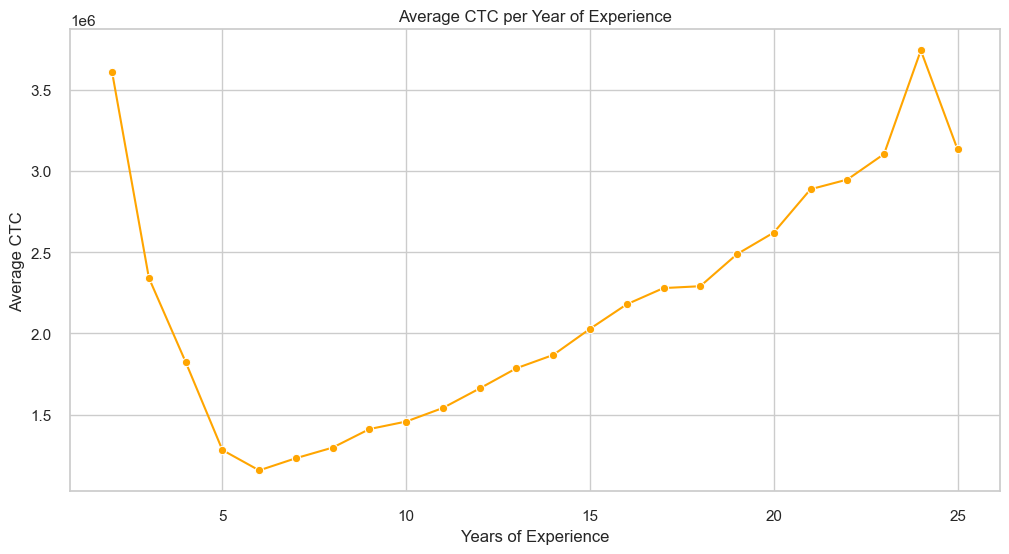

In [61]:
# Calculate average CTC per year of experience
avg_ctc_per_yoe = df3.groupby('YOE_capped')['ctc_capped'].mean().reset_index()

# Line plot with markers
plt.figure(figsize=(12, 6))
sns.lineplot(x='YOE_capped', y='ctc_capped', data=avg_ctc_per_yoe, marker='o', color='orange')
plt.title('Average CTC per Year of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Average CTC')

plt.show()

* Avg. CTC is decreasing from 1 to 5 years of Experience. There might be a slight decrease in CTC with increasing experience, possibly due to industry-specific factors or career shifts.
* From 5 to 23 years it is showing natural increase in CTC, then again a drop from 23 to 24 years

**Q. Name job position that is commonly considered entry-level but has a few learners with unusually high CTCs in the dataset.**

In [62]:
# Identify common entry-level job positions
entry_level_positions = ['Junior Engineer', 'Intern', 'Trainee', 'Associate', 'Entry Level Engineer']

# Filter the dataframe for these positions
entry_level_df = df3[df3['job_position'].isin(entry_level_positions)]

# Group by job position and calculate statistics
grouped_positions = entry_level_df.groupby('job_position')['ctc_capped'].agg(['mean', 'max']).reset_index()

# Calculate the threshold to identify unusually high CTCs (e.g., 2 times the mean)
grouped_positions['high_ctc_threshold'] = grouped_positions['mean'] * 2

# Find job positions where the max CTC is greater than the high CTC threshold
unusually_high_ctcs = grouped_positions[grouped_positions['max'] > grouped_positions['high_ctc_threshold']]

print(unusually_high_ctcs)

  job_position      mean      max  high_ctc_threshold
0    Associate  646000.0  1500000           1292000.0


Associate is one job position considered as entry level but maximum CTC going beyond set threshold

**Q. What is the average CTC of learners across different job positions?**

In [63]:
# Group by job position and calculate the average CTC
average_ctc_by_position = df3.groupby('job_position')['ctc_capped'].mean().reset_index()

# Rename the columns for clarity
average_ctc_by_position.columns = ['job_position', 'average_ctc']

# Sort the result by average CTC in descending order
average_ctc_by_position = average_ctc_by_position.sort_values(by='average_ctc', ascending=False)

# Print the result
average_ctc_by_position

,job_position,average_ctc
218,Jharkhand,24000000.0
594,Telar,24000000.0
289,Owner,24000000.0
343,Reseller,24000000.0
565,Teaching,24000000.0
...,...,...
257,Matlab programmer,10000.0
222,Junior Software developer,10000.0
642,project engineer,7900.0
189,Full-stack web developer,7500.0


**Q.For a given company, how does the average CTC of a Data Scientist compare with other roles?**

In [64]:
# Filter the dataframe for rows where job_position is 'Data Scientist'
data_scientist_df = df3[df3['job_position'] == 'Data Scientist']

# Get the unique companies that have the job position 'Data Scientist'
companies_with_data_scientist = data_scientist_df['company_hash'].unique()

# Print the result
print("Companies with 'Data Scientist' job position:")
print(companies_with_data_scientist)

Companies with 'Data Scientist' job position:
['ngpgutaxv' 'wgszxkvzn' 'xznhxn' ... 'mgongz xcj ytvrnywvqt ucn rna'
 'uvny' 'wgbuzgcv wgznqvwn']


In [65]:
company_hash_given = 'xznhxn'

# Filter the dataframe for the given company
df_company = df3[df3['company_hash'] == company_hash_given]

# Calculate the average CTC for Data Scientist role
data_scientist_ctc = df_company[df_company['job_position'] == "Data Scientist"]['ctc_capped'].mean()

# Calculate the average CTC for all other roles
other_roles_ctc = df_company[df_company['job_position'] != "Data Scientist"]['ctc_capped'].mean()

# Print the result
print(f"Average CTC for Data Scientist in company {company_hash_given}: {data_scientist_ctc}")
print(f"Average CTC for all other roles in company {company_hash_given}: {other_roles_ctc}")

# Compare the two values
if not pd.isna(data_scientist_ctc) and not pd.isna(other_roles_ctc):
    if data_scientist_ctc > other_roles_ctc:
        print("Data Scientists have a higher average CTC compared to other roles.")
    elif data_scientist_ctc < other_roles_ctc:
        print("Data Scientists have a lower average CTC compared to other roles.")
    else:
        print("Data Scientists have the same average CTC as other roles.")
else:
    print("Data Scientist role or other roles not found in the given company.")

Average CTC for Data Scientist in company xznhxn: 4833333.333333333
Average CTC for all other roles in company xznhxn: 2816223.105527638
Data Scientists have a higher average CTC compared to other roles.


**CTC by Job Position**

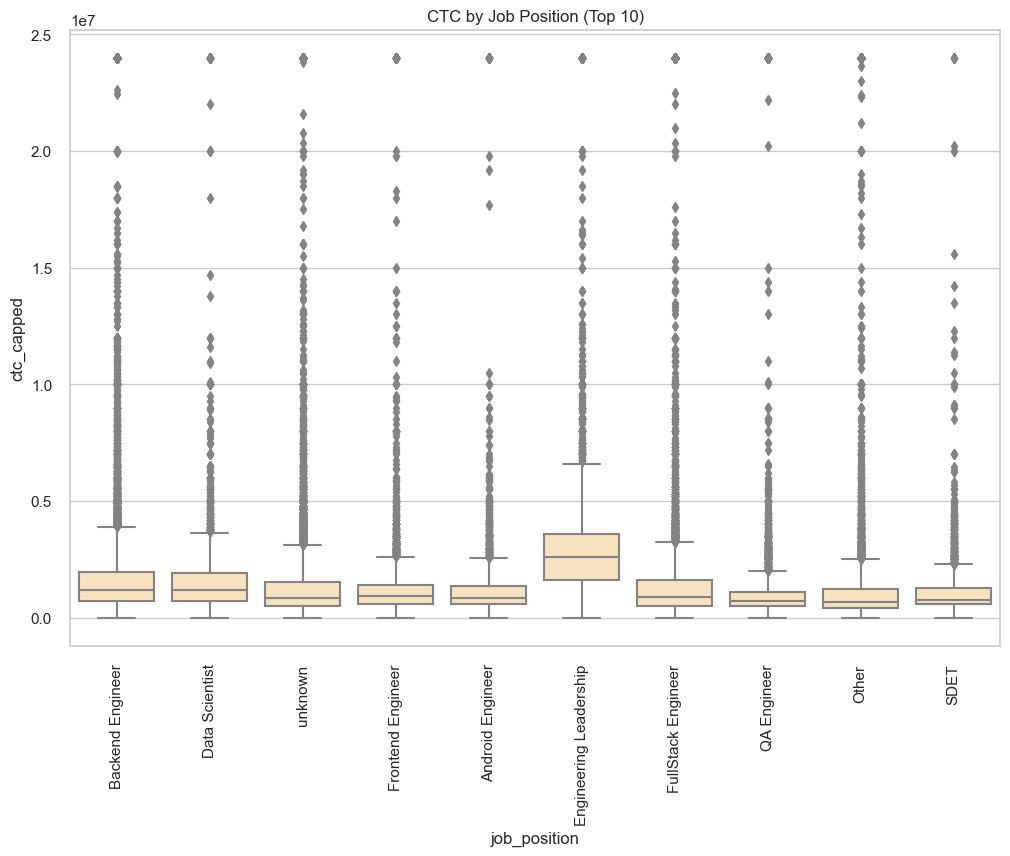

In [66]:
# Get the top 10 job positions by count
top_10_job_positions = df3['job_position'].value_counts().nlargest(10).index

# Filter the dataset to include only the top 10 job positions
df_top_10 = df3[df3['job_position'].isin(top_10_job_positions)]

# Plot the box plot for CTC by Job Position
plt.figure(figsize=(12, 8))
sns.boxplot(x='job_position', y='ctc_capped', data=df_top_10, color='moccasin')
plt.title('CTC by Job Position (Top 10)')
plt.xticks(rotation=90)
plt.show()

CTC is highest for Engineering Leadership followed by Backend Engineer and Data Scientist

**Years of Experience by Job Position**

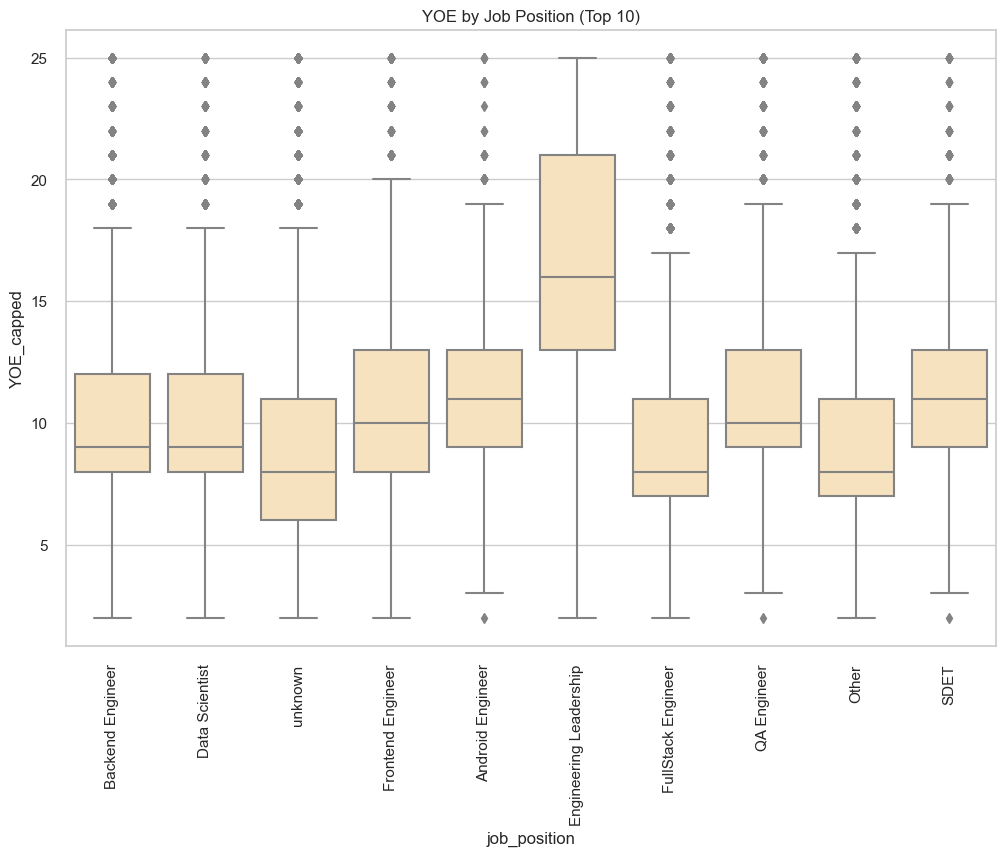

In [67]:
# Get the top 10 job positions by count
top_10_job_positions = df3['job_position'].value_counts().nlargest(10).index

# Filter the dataset to include only the top 10 job positions
df_top_10 = df3[df3['job_position'].isin(top_10_job_positions)]

# Plot the box plot for YOE by Job Position
plt.figure(figsize=(12, 8))
sns.boxplot(x='job_position', y='YOE_capped', data=df_top_10,color='moccasin')
plt.xticks(rotation=90)
plt.title('YOE by Job Position (Top 10)')
plt.show()

Years of Experience is highest for Engineering Leadership followed by Android Engineer and SDET

**Correlation Heatmap**

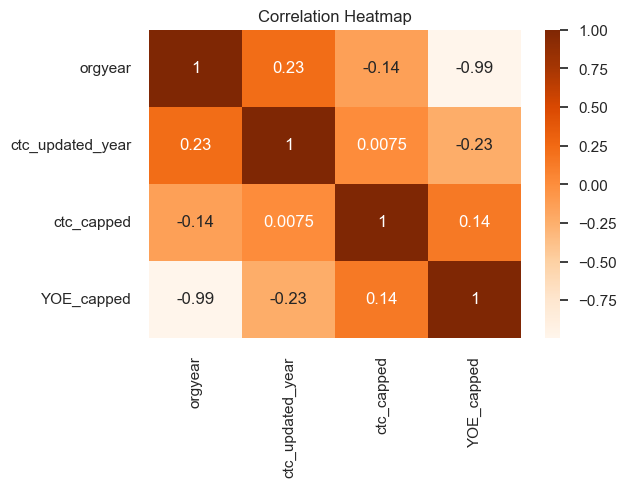

In [68]:
plt.figure(figsize=(6, 4))
sns.heatmap(df3[['orgyear', 'ctc_updated_year', 'ctc_capped', 'YOE_capped']].corr(), annot=True, cmap='Oranges')
plt.title('Correlation Heatmap')
plt.show()

* orgyear and ctc_updated_year shown weak positive correlation
* Years of Experience and orgyear show strong negative correlation
* Years of Experience and CTC show weak positive correaltion

**Statistical Summary**

In [69]:
df2.describe(include='object')

,company_hash,email_hash,job_position
count,153443,153443,153443
unique,36366,153443,653
top,nvnv wgzohrnvzwj otqcxwto,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,unknown
freq,5336,1,34189


In [70]:
df2.describe()

,orgyear,ctc,ctc_updated_year,YOE,ctc_capped,YOE_capped
count,153443.000000,1.534430e+05,153443.00000,153443.000000,1.534430e+05,153443.000000
mean,2014.811467,2.501398e+06,2019.42172,10.188533,1.572051e+06,10.153744
std,4.369586,1.307523e+07,1.36023,4.369586,2.670005e+06,4.212774
min,1900.000000,2.000000e+00,2015.00000,2.000000,2.000000e+00,2.000000
25%,2013.000000,5.500000e+05,2019.00000,7.000000,5.500000e+05,7.000000
50%,2016.000000,9.500000e+05,2019.00000,9.000000,9.500000e+05,9.000000
75%,2018.000000,1.700000e+06,2020.00000,12.000000,1.700000e+06,12.000000
max,2023.000000,1.000150e+09,2021.00000,125.000000,2.400000e+07,25.000000


* Dataset have got 36366 unique companies
* There are 153443 unique learners
* And 652 unique job positions
* Minimum year of Employment starting date is 1900 and maximum is 2023
* Minimum CTC is 2 and maximum 2.4 cr after capping
* Minimum Years of experience is 1 and maximum is 24 after capping

# Data Processing for Unsupervised Learning
* Encoding
* Scaling
* Feature Engineering
* Log Transformation

In [71]:
df4 = df3.drop(['Designation_Flag', 'Class_Flag', 'Tier_Flag'], axis=1)

Removing these flags from the prepared data since they were meant for Manual Clustering



In [72]:
dfcopy=df.copy()

In [73]:
# Calculate frequency of email_hash in dfcopy
email_hash_freq = dfcopy['email_hash'].value_counts().reset_index()
email_hash_freq.columns = ['email_hash', 'no_of_ctc_update']

# Merge with df4 on email_hash
df4_merged = pd.merge(df4, email_hash_freq, on='email_hash', how='left')

Created a new feature 'no_of_ctc_update' signifying the number of times CTC got updated of a learner which is derived from frequency of email_hash in the dataset

In [74]:
df4_merged=df4_merged.drop(['email_hash', 'orgyear', 'ctc_updated_year'], axis=1)

Removing followng columns:

* email_hash: It is unique for each row and do not provide useful information for clustering
* orgyear: We have got Years of Experience derived from this feature which is more relevant then just the year of joining for clustering algorithm
* ctc_updated_year: We have derived a feature no. of ctc update signifying number of times ctc got updated of a learner which is more relevant to clustering algorithm than mere year as a timeline or int

In [75]:
df4_merged.head()


,company_hash,job_position,ctc_capped,YOE_capped,no_of_ctc_update
0,ngpgutaxv,Backend Engineer,700000,8,1
1,ngpgutaxv,Backend Engineer,1200000,8,2
2,ngpgutaxv,Backend Engineer,800000,8,1
3,ngpgutaxv,Backend Engineer,1600000,8,2
4,ngpgutaxv,Backend Engineer,1210000,8,2


In [76]:
df5=df4_merged.copy()

**Encoding non-numerical columns**

Frequency Encoding replaces each categorical value with its frequency in the dataset. A good compromise between simplicity and capturing categorical variable importance.

In [77]:
# Frequency encoding for company_hash
company_hash_freq = df4_merged['company_hash'].value_counts().to_dict()
df4_merged['company_hash_encoded'] = df4_merged['company_hash'].map(company_hash_freq)

# Frequency encoding for job_position
job_position_freq = df4_merged['job_position'].value_counts().to_dict()
df4_merged['job_position_encoded'] = df4_merged['job_position'].map(job_position_freq)

In [78]:
df4_merged=df4_merged.drop(['company_hash', 'job_position'], axis=1)

In [79]:
df4_merged.head()

,ctc_capped,YOE_capped,no_of_ctc_update,company_hash_encoded,job_position_encoded
0,700000,8,1,53,33154
1,1200000,8,2,53,33154
2,800000,8,1,53,33154
3,1600000,8,2,53,33154
4,1210000,8,2,53,33154


**Log Transformation**

Applying Log Transformation on ctc_capped column since it is right skewed. Since skewness can affect performance of clustering algorithms

In [80]:
df4_merged['ctc_capped_log'] = np.log1p(df4_merged['ctc_capped'])

In [81]:
df4_merged=df4_merged.drop(['ctc_capped'], axis=1)

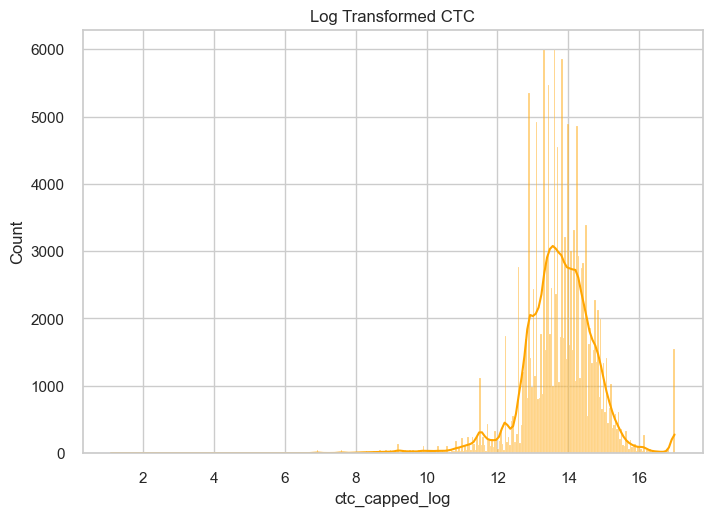

In [82]:
sns.histplot(df4_merged['ctc_capped_log'], kde=True,color='orange')
plt.title('Log Transformed CTC')
plt.show()

After applying log transformation, the feature shows normal distribution

In [83]:
df4_merged.head()

,YOE_capped,no_of_ctc_update,company_hash_encoded,job_position_encoded,ctc_capped_log
0,8,1,53,33154,13.458837
1,8,2,53,33154,13.997833
2,8,1,53,33154,13.592368
3,8,2,53,33154,14.285515
4,8,2,53,33154,14.006132


**Standard Scaling**

In [84]:
from sklearn.preprocessing import StandardScaler

In [85]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
scaled_features = scaler.fit_transform(df4_merged[['YOE_capped', 'no_of_ctc_update', 'company_hash_encoded', 'job_position_encoded', 'ctc_capped_log']])

#Convert th scaled features back to a dataframe
df_scaled = pd.DataFrame(scaled_features, columns=['YOE_capped', 'no_of_ctc_update', 'company_hash_encoded', 'job_position_encoded', 'ctc_capped_log'])
df_scaled.head()

,YOE_capped,no_of_ctc_update,company_hash_encoded,job_position_encoded,ctc_capped_log
0,-0.511243,-0.530558,-0.45349,1.025768,-0.271471
1,-0.511243,1.023076,-0.45349,1.025768,0.247746
2,-0.511243,-0.530558,-0.45349,1.025768,-0.142840
3,-0.511243,1.023076,-0.45349,1.025768,0.524871
4,-0.511243,1.023076,-0.45349,1.025768,0.255740


# Model Building
* K-means Clustering
* Hierarchical Clustering

**Checking Clustering Tendency- Hopkins Statistics**

In [86]:
def hopkins_statistic(X):
    X = np.array(X)  # Ensure X is a numpy array
    d = X.shape[1]  # Number of dimensions
    n = len(X)  # Number of data points
    m = int(0.1 * n)  # Subset size (10% of the data points)
    
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    rand_X = np.random.random((m, d)) * np.amax(X, axis=0)
    u_distances, _ = nbrs.kneighbors(rand_X, 2, return_distance=True)

    w_distances, _ = nbrs.kneighbors(X[np.random.choice(n, m, replace=False)], 2, return_distance=True)

    u_distances = u_distances[:, 1]
    w_distances = w_distances[:, 1]

    H = (np.sum(u_distances) / (np.sum(u_distances) + np.sum(w_distances)))
    return H
    

hopkins_score = hopkins_statistic(df_scaled)
print(f"Hopkins Statistic: {hopkins_score}")

Hopkins Statistic: 0.9827537584944728


The value is very close to 1, which means that the dataset has a very strong clustering structure. It is likely to form well defined clusters

**Elbow Method- To select optimal number of clusters**

**Inertia**

Within Cluster Sum of Squares. This metric measures how tightly the clusters are packed. Lower inertia values indicate better-defined clusters.

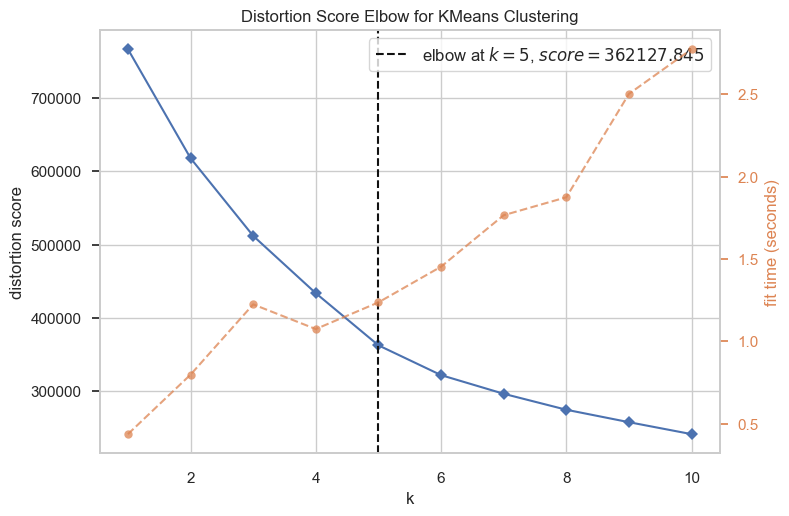

<AxesSubplot: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [87]:
model = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(model, k=(1, 11))
visualizer.fit(df_scaled)        # Fit data to visualizer
visualizer.show()        # Finalize and render figure

The elbow point suggests that 5 clusters is a good choice for our data. This is where the inertia starts to decrease at a slower rate, indicating that additional clusters beyond this point don't significantly improve the clustering quality.

**K-Means Clustering**

In [88]:
optimal_clusters = 5  # Set the optimal number of clusters as found above
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans.fit(df_scaled)

# Adding cluster labels to the DataFrame
df5['kmeans_cluster'] = kmeans.labels_

In [89]:
df5.head()

,company_hash,job_position,ctc_capped,YOE_capped,no_of_ctc_update,kmeans_cluster
0,ngpgutaxv,Backend Engineer,700000,8,1,2
1,ngpgutaxv,Backend Engineer,1200000,8,2,3
2,ngpgutaxv,Backend Engineer,800000,8,1,2
3,ngpgutaxv,Backend Engineer,1600000,8,2,3
4,ngpgutaxv,Backend Engineer,1210000,8,2,3


In [90]:
df5.kmeans_cluster.value_counts()

0    50630
2    40349
3    30033
1    23574
4     8857
Name: kmeans_cluster, dtype: int64

**Hierarchical Clustering**

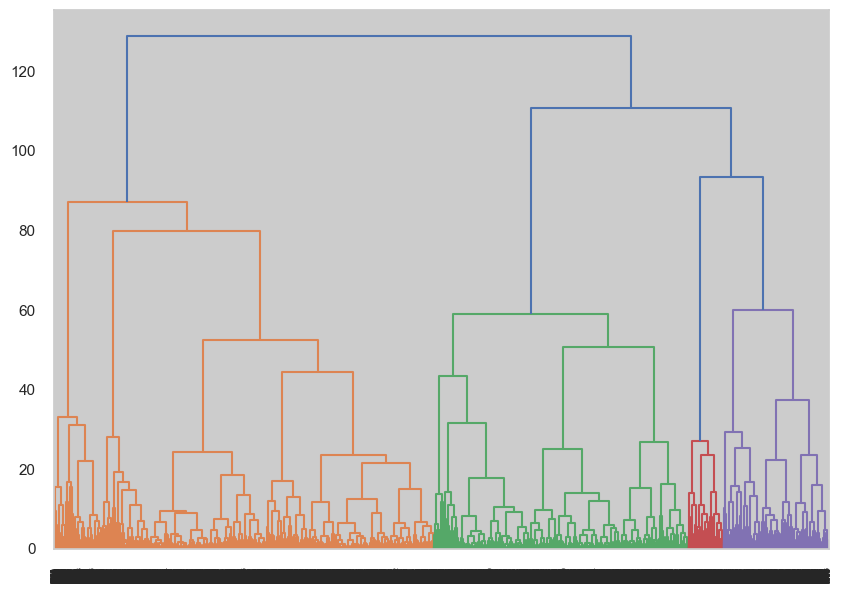

In [91]:
# Sample a subset of the data
df_sampled = df_scaled.sample(n=10000, random_state=42)

# Perform hierarchical clustering
Z = linkage(df_sampled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.show()

* Used Representative subset of data to avoid running out of memory.
* Dendogram is showing 5 different colored branches at the end representing 5 clusters

Both Elbow Method and Dendogram are suggesting 5 clusters for the given dataset

# Evaluation of K-means Clustering

**Within-Cluster Sum of Squares (WCSS)**

The Within-Cluster Sum of Squares (WCSS) is a measure of the compactness of the clusters formed by the K-means algorithm. It represents the sum of squared distances between each data point and its corresponding cluster centroid. A lower WCSS value indicates tighter clusters, meaning that the data points within each cluster are closer to their respective centroid.

In [92]:
wcss = kmeans.inertia_
print(f'Within-Cluster Sum of Squares (WCSS): {wcss}')

Within-Cluster Sum of Squares (WCSS): 362130.79343430046


WCSS Value Consistency: The WCSS value remains consistent at 362130.79343430046 for 𝑘=5. This value represents the total within-cluster variance for the five clusters formed by K-means.

**Between-Cluster Sum of Squares (BCSS)**

This value represents the total squared distance between each cluster centroid and the overall mean of the data, weighted by the number of points in each cluster. A higher BCSS indicates that the cluster centroids are far from the overall mean, suggesting well-separated clusters.

In [93]:
# Assuming df_scaled is your scaled dataframe
df_scaled_copy = df_scaled.copy()

# Adding cluster labels to the DataFrame
df_scaled_copy['kmeans_cluster'] = kmeans.labels_

# Between-Cluster Sum of Squares (BCSS)
def calculate_bcss(df, kmeans):
    cluster_centers = kmeans.cluster_centers_
    overall_mean = df.drop(columns='kmeans_cluster').mean(axis=0)
    bcss = 0 
    for i, center in enumerate(cluster_centers):
        size = len(df[df['kmeans_cluster'] == i])
        bcss += size * np.sum((center - overall_mean) ** 2)
    return bcss
    
bcss = calculate_bcss(df_scaled_copy, kmeans)
print(f'Between-Cluster Sum of Squares (BCSS): {bcss}')

Between-Cluster Sum of Squares (BCSS): 404845.9938956743


High BCSS and Low WCSS: The combination of a relatively high BCSS and a relatively low WCSS is desirable. It means that the clusters are well-separated and compact.

**Visual Inspection- PCA**

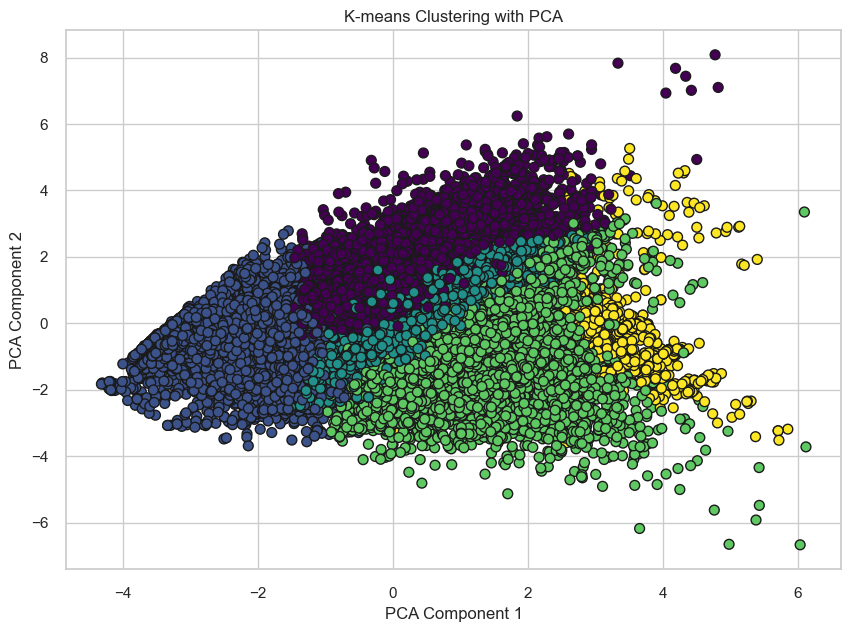

In [94]:
#Visual Inspection using PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled_copy.drop(columns='kmeans_cluster'))

df_scaled_copy['pca_one'] = pca_result[:, 0]
df_scaled_copy['pca_two'] = pca_result[:, 1]

plt.figure(figsize=(10, 7))
plt.scatter(df_scaled_copy['pca_one'], df_scaled_copy['pca_two'], c=df_scaled_copy['kmeans_cluster'], cmap='viridis',  marker='o', edgecolor='k', s=50)
plt.title('K-means Clustering with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

Above we can visualize 5 clusters



# Cluster Profile and Key Characteristics

**Cluster Size and Distribution**

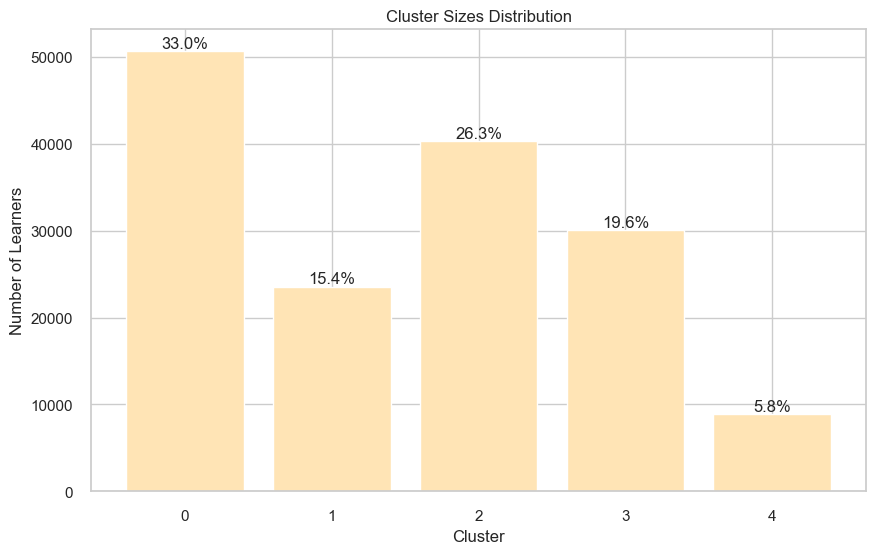

In [95]:
# Assuming cluster sizes are stored in a dictionary
cluster_sizes = {0: 50630, 1: 23574, 2: 40349, 3: 30033, 4: 8857}

# Calculate the total number of learners
total_learners = sum(cluster_sizes.values())

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_sizes.keys(), cluster_sizes.values(), color="moccasin")

# Add percentage labels above the bars
for bar in bars:
    height = bar.get_height()
    percentage = (height / total_learners) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{percentage:.1f}%', ha='center', va='bottom')

# Add labels and title
plt.xlabel('Cluster')
plt.ylabel('Number of Learners')
plt.title('Cluster Sizes Distribution')
plt.show()

The clustering analysis resulted in 5 distinct clusters with the following sizes:

* Cluster 0: 50,630 learners (33.0%)
* Cluster 1: 23,574 learners (15.4%)
* Cluster 2: 40,349 learners (26.3%)
* Cluster 3: 30,033 learners (19.6%)
* Cluster 4: 8,857 learners (5.8%)

This distribution indicates that Cluster 0 is the largest segment, representing a significant portion of our learner base.

**CTC / Years of Exp / CTC_updates distribution across Clusters**

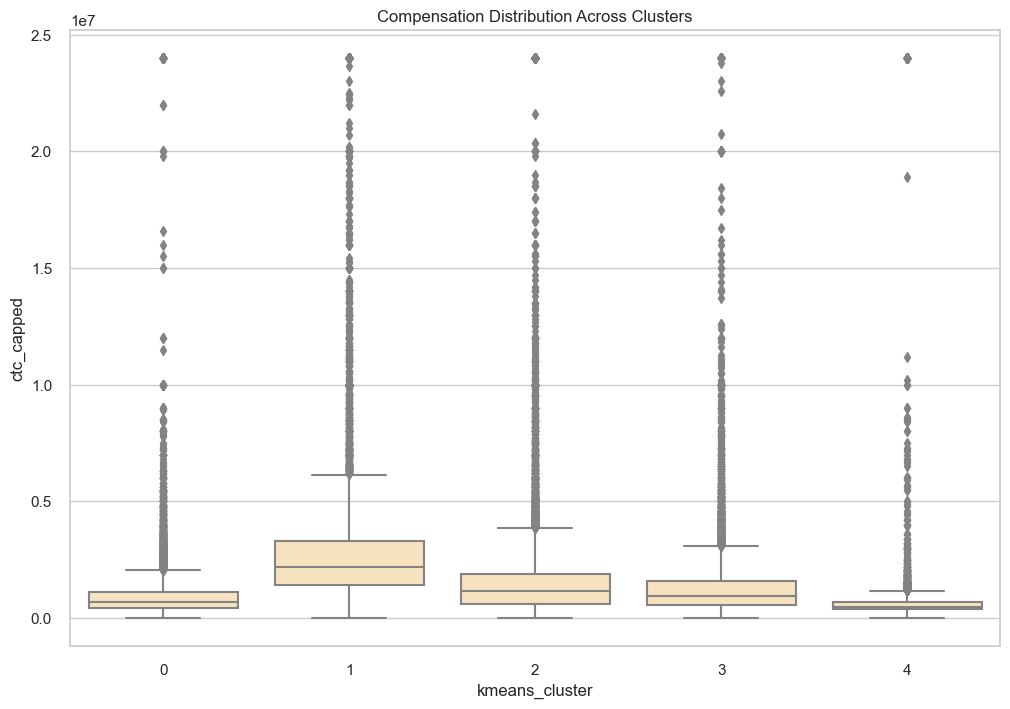

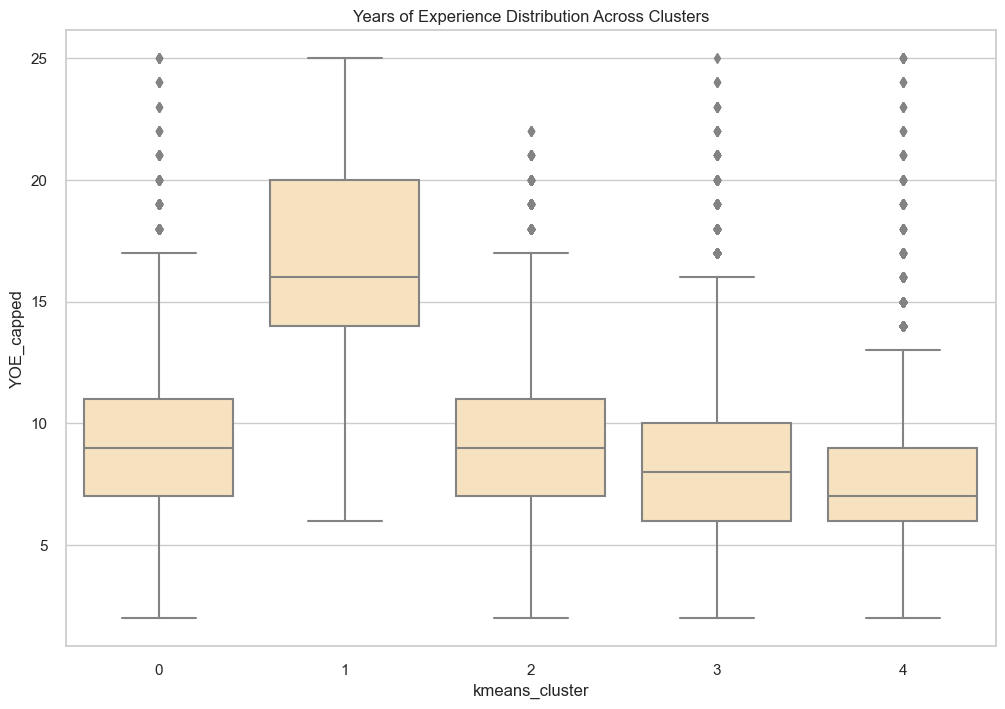

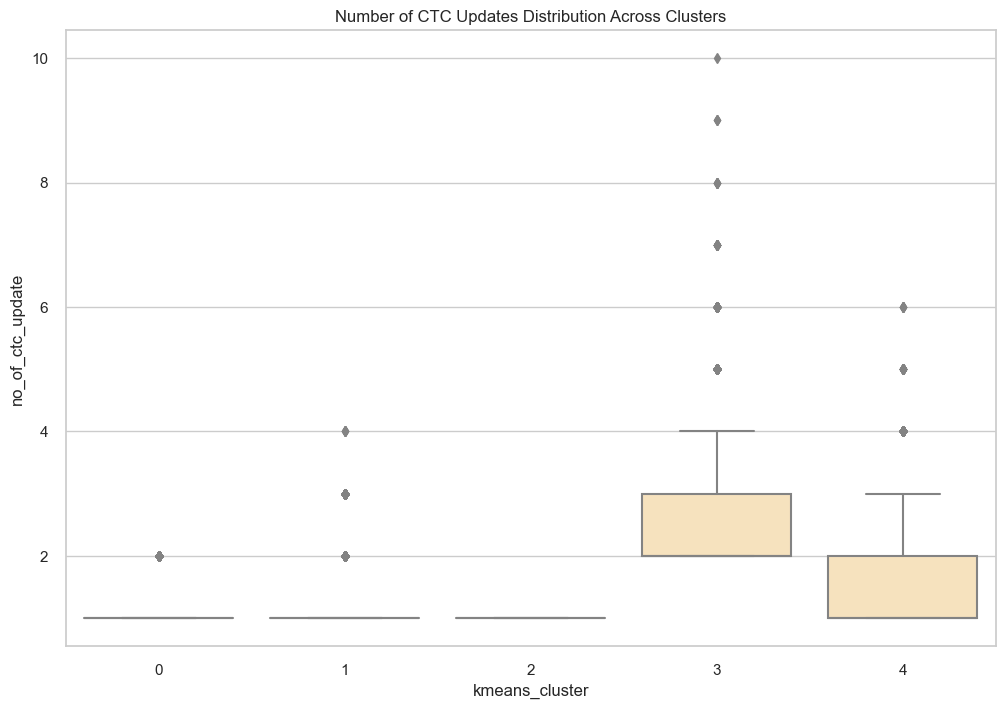

In [96]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='kmeans_cluster', y='ctc_capped', data=df5,color='moccasin')
plt.title('Compensation Distribution Across Clusters')
plt.show()

plt.figure(figsize=(12, 8))
sns.boxplot(x='kmeans_cluster', y='YOE_capped', data=df5,color='moccasin')
plt.title('Years of Experience Distribution Across Clusters')
plt.show()

plt.figure(figsize=(12, 8))
sns.boxplot(x='kmeans_cluster', y='no_of_ctc_update', data=df5, color='moccasin')
plt.title('Number of CTC Updates Distribution Across Clusters')
plt.show()

* Compensation is high for cluster 1 followed by cluster 2
* Years of Experience is highest for cluster 1 followed by 2 and 1
* CTC_updates is high for cluster 3 followed by 4
* Compensation and Years of Exp is relatively higher for cluster 1

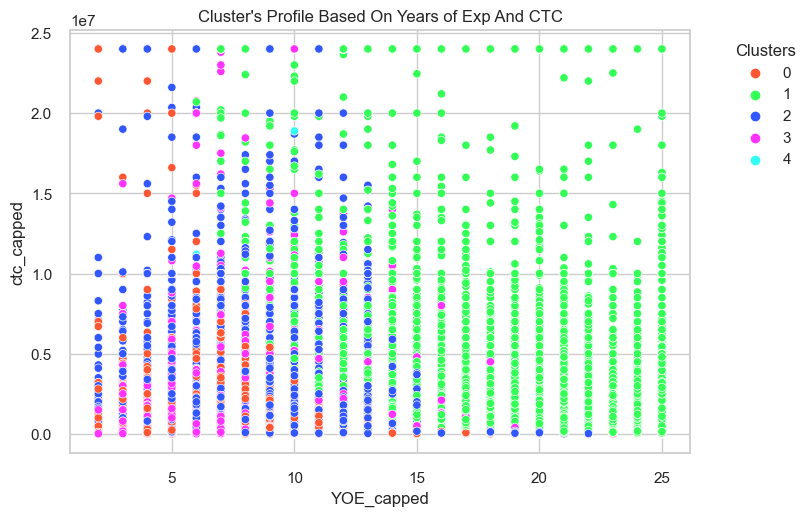

In [97]:
# Define a custom color palette with distinct colors
custom_palette = sns.color_palette(["#FF5733", "#33FF57", "#3357FF", "#FF33FF", "#33FFF3"])

# Create the scatter plot with the custom palette
pl = sns.scatterplot(data=df5, x="YOE_capped", y="ctc_capped", hue="kmeans_cluster", palette=custom_palette)

# Set the title
pl.set_title("Cluster's Profile Based On Years of Exp And CTC")

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Clusters')

# Show the plot
plt.show()

* Cluster 3 has relatively higher years of experience and compensation which was reflected from above box plots too
* Cluster 1 has lesser years of experience and w.r.t cluster 3 and most of the compensation is lower

In [98]:

# Select only numeric columns for aggregation
numeric_columns = ['ctc_capped', 'YOE_capped', 'no_of_ctc_update']

# Calculate mean values for each cluster
cluster_averages = df5.groupby('kmeans_cluster')[numeric_columns].mean()

# Display the average values for each cluste
print(cluster_averages)

                  ctc_capped  YOE_capped  no_of_ctc_update
kmeans_cluster                                            
0               9.012630e+05    9.020719          1.091389
1               3.408064e+06   16.942988          1.121023
2               1.699614e+06    9.219931          1.000000
3               1.313836e+06    8.616355          2.335364
4               8.142048e+05    8.027323          1.543638


In [99]:
from collections import Counter

# Function to get the most common job positions and companies in each cluster
def get_common_entries(df, cluster_label, column_name, top_n=3):
    cluster_data = df[df['kmeans_cluster'] == cluster_label]
    most_common_entries = Counter(cluster_data[column_name]).most_common(top_n)
    return most_common_entries

# Get profiles for each cluster
cluster_profiles = {}

for cluster in range(5):
    job_positions = get_common_entries(df5, cluster, 'job_position')
    companies = get_common_entries(df5, cluster, 'company_hash')

    cluster_profiles[cluster] = {
        'average_ctc': cluster_averages.loc[cluster, 'ctc_capped'],
        'average_yoe': cluster_averages.loc[cluster, 'YOE_capped'],
        'average_ctc_updates': cluster_averages.loc[cluster, 'no_of_ctc_update'],
        'common_job_positions': job_positions,
        'common_companies': companies
    }

# Display the profiles
for cluster, profile in cluster_profiles.items():
    print(f"Cluster {cluster}:")
    print(f"  Average Compensation (CTC): {profile['average_ctc']}")
    print(f"  Average Years of Experience: {profile['average_yoe']} years")
    print(f"  Average Number of CTC Updates: {profile['average_ctc_updates']}")
    print("  Common Job Positions:")
    for job, count in profile['common_job_positions']:
        print(f"    - {job}: {count} occurrences")
    print("  Common Companies:")
    for company, count in profile['common_companies']:
        print(f"    - {company}: {count} occurrences")
    print()

Cluster 0:
  Average Compensation (CTC): 901262.9691092238
  Average Years of Experience: 9.020718941339126 years
  Average Number of CTC Updates: 1.0913885048390282
  Common Job Positions:
    - FullStack Engineer: 8329 occurrences
    - Other: 7995 occurrences
    - Frontend Engineer: 5235 occurrences
  Common Companies:
    - wgszxkvzn: 859 occurrences
    - vwwtznhqt: 707 occurrences
    - zgn vuurxwvmrt vwwghzn: 696 occurrences

Cluster 1:
  Average Compensation (CTC): 3408064.308008823
  Average Years of Experience: 16.942988037668616 years
  Average Number of CTC Updates: 1.121023161109697
  Common Job Positions:
    - Engineering Leadership: 4621 occurrences
    - FullStack Engineer: 1984 occurrences
    - Other: 1927 occurrences
  Common Companies:
    - gqvwrt: 346 occurrences
    - bxwqgogen: 296 occurrences
    - lubgqsvz wyvot  wg: 253 occurrences

Cluster 2:
  Average Compensation (CTC): 1699613.82467967
  Average Years of Experience: 9.219931101142532 years
  Average Num

# Insights

Cluster 0:

* This cluster consists of individuals with mid-level experience (around 9 years).
* They have a moderately high average compensation.
* Frontend Engineer and FullStack Engineers are prominent roles apart from 'other'.
* Common employers include companies like zgn vuurxwvmrt vwwghzn, vwwtznhqt and wgszxkvzn.

Cluster 1:

* Individuals in this cluster have more experience on average compared to Cluster 0.
* The average compensation is higher than Cluster 0.
* Engineering Leadership and FullStack Engineer are prevalent.
* The "Other" category indicates a diverse range of job positions.

Cluster 2:

* This cluster has individuals with high compensation and above-average experience.
* Backend Engineers dominate this cluster, indicating a specialized skill set.
* There's a significant number of "unknown" job positions.
* Key employers include vbvkgz and zgn vuurxwvmrt.

Cluster 3:

* This cluster represents highly experienced professionals with significantly high compensation.
* The predominant role is in "Unknown", indicating senior positions.
* The diversity in job positions (FullStack Engineer and Backend Engineer) suggests a variety of responsibilities even among senior staff.

Cluster 4:

* Individuals in this cluster have lower compensation and slightly less experience compared to other clusters.
* Backend Engineers are common, but there's also a significant "Other" category.
* The most frequent employers are nvnv wgzohrnvzwj, otqcxwto and xzegojo, which are distinct from those in other clusters.

# Recommendations

* Personalized Learning Paths: Implement personalized learning paths based on the cluster profiles. Utilize data to recommend courses that align with individual career goals and current industry trends.

* Exclusive Content and Membership Tiers: Develop exclusive content and membership tiers for high-value clusters, providing advanced learning opportunities and industry insights.

* Loyalty Programs and Incentives: Create loyalty programs to encourage continued learning and engagement. Offer incentives such as discounts, exclusive access, and career coaching.

* Targeted Marketing Campaigns: Design marketing campaigns that address the specific needs and preferences of each cluster. Use success stories, testimonials, and case studies to highlight the benefits of Scaler’s programs.


By implementing these recommendations, Scaler can enhance its engagement with learners, improve retention rates, and maximize the ROI of its educational programs.